CLEANING DATA

In [20]:
import pandas as pd
#FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set pd.set_option('future.no_silent_downcasting', True) df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])
pd.set_option('future.no_silent_downcasting', True)
# ── Load Data ──────────────────────────────────────────────────────────────────
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

# ── Master Cleaning Function ───────────────────────────────────────────────────
def clean_df(df):
    df = df.copy()

    # ── 1. Extract Group ID from PassengerId ──────────────────────────────────
    # PassengerId format: "0001_01" → Group = "0001"
    df['Group'] = df['PassengerId'].str.split('_').str[0]

    # ── 2. Spending Columns ───────────────────────────────────────────────────
    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    # CryoSleep passengers are frozen → they cannot spend anything → fill with 0
    df.loc[df['CryoSleep'] == True, spending_cols] = (
        df.loc[df['CryoSleep'] == True, spending_cols].fillna(0)
    )

    # Remaining NaNs (CryoSleep=False or unknown) → fill with median
    for col in spending_cols:
        df[col] = df[col].fillna(df[col].median())

    # ── 3. TotalSpend (needed to infer CryoSleep) ─────────────────────────────
    df['TotalSpend'] = df[spending_cols].sum(axis=1)

    # ── 4. CryoSleep ─────────────────────────────────────────────────────────
    # If a passenger spent anything → they are definitely NOT in CryoSleep
    df.loc[(df['CryoSleep'].isnull()) & (df['TotalSpend'] > 0),  'CryoSleep'] = False
    # If they spent nothing → assume CryoSleep = True
    df.loc[(df['CryoSleep'].isnull()) & (df['TotalSpend'] == 0), 'CryoSleep'] = True

    # ── 5. HomePlanet ─────────────────────────────────────────────────────────
    # People in the same group likely board from the same planet
    df['HomePlanet'] = df.groupby('Group')['HomePlanet'].transform(
        lambda x: x.fillna(x.mode()[0]) if x.notna().any() else x
    )
    # Fallback → overall mode
    df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])

    # ── 6. Cabin → Split into Deck / RoomNumber / Side ───────────────────────
    df[['Deck', 'RoomNumber', 'Side']] = df['Cabin'].str.split('/', expand=True)

    # Fill Side using group logic then mode fallback
    df['Side'] = df.groupby('Group')['Side'].transform(
        lambda x: x.fillna(x.mode()[0]) if x.notna().any() else x
    )
    df['Side'] = df['Side'].fillna(df['Side'].mode()[0])

    # Fill Deck using group logic then mode fallback
    df['Deck'] = df.groupby('Group')['Deck'].transform(
        lambda x: x.fillna(x.mode()[0]) if x.notna().any() else x
    )
    df['Deck'] = df['Deck'].fillna(df['Deck'].mode()[0])

    # Fill RoomNumber with median (it's a number not a category)
    df['RoomNumber'] = df['RoomNumber'].fillna(
        df['RoomNumber'].astype(float).median()
    )

    # Reconstruct Cabin from the 3 parts
    df['Cabin'] = df['Deck'] + '/' + df['RoomNumber'].astype(str) + '/' + df['Side']

    # ── 7. Destination ────────────────────────────────────────────────────────
    df['Destination'] = df.groupby('Group')['Destination'].transform(
        lambda x: x.fillna(x.mode()[0]) if x.notna().any() else x
    )
    df['Destination'] = df['Destination'].fillna(df['Destination'].mode()[0])

    # ── 8. Age ────────────────────────────────────────────────────────────────
    df['Age'] = df['Age'].fillna(df['Age'].median())

    # ── 9. VIP ────────────────────────────────────────────────────────────────
    df['VIP'] = df.groupby('Group')['VIP'].transform(
        lambda x: x.fillna(x.mode()[0]) if x.notna().any() else x
    )
    df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])

    # ── 10. Drop Name (not useful for modelling) ──────────────────────────────
    df = df.drop(columns=['Name'])

    return df

# ── Apply to Both ──────────────────────────────────────────────────────────────
train_clean = clean_df(train)
test_clean  = clean_df(test)

# ── Verify — No Missing Values ─────────────────────────────────────────────────
print("=== TRAIN MISSING VALUES ===")
print(train_clean.isnull().sum().sort_values(ascending=False).head(10))

print("\n=== TEST MISSING VALUES ===")
print(test_clean.isnull().sum().sort_values(ascending=False).head(10))

print("\nTrain shape:", train_clean.shape)
print("Test shape: ", test_clean.shape)

# ── Save ───────────────────────────────────────────────────────────────────────
train_clean.to_csv('train_clean.csv', index=False)
test_clean.to_csv('test_clean.csv',   index=False)

print("\n✅ train_clean.csv and test_clean.csv saved successfully!")


=== TRAIN MISSING VALUES ===
PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
dtype: int64

=== TEST MISSING VALUES ===
PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
dtype: int64

Train shape: (8693, 18)
Test shape:  (4277, 17)

✅ train_clean.csv and test_clean.csv saved successfully!


EDA - Understanding the data


 RUNNING FULL EDA SUITE

=== Transported Value Counts ===
Transported
True     4378
False    4315
Name: count, dtype: int64

=== Transported Percentage ===
Transported
True     50.36%
False    49.64%
Name: proportion, dtype: object


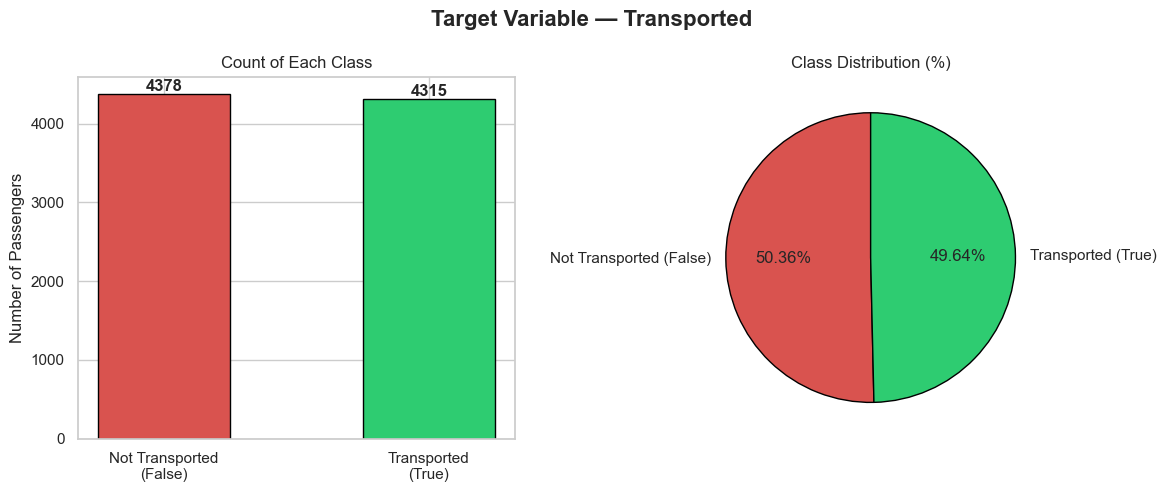


✅ Plot saved as eda_2a_target_variable.png


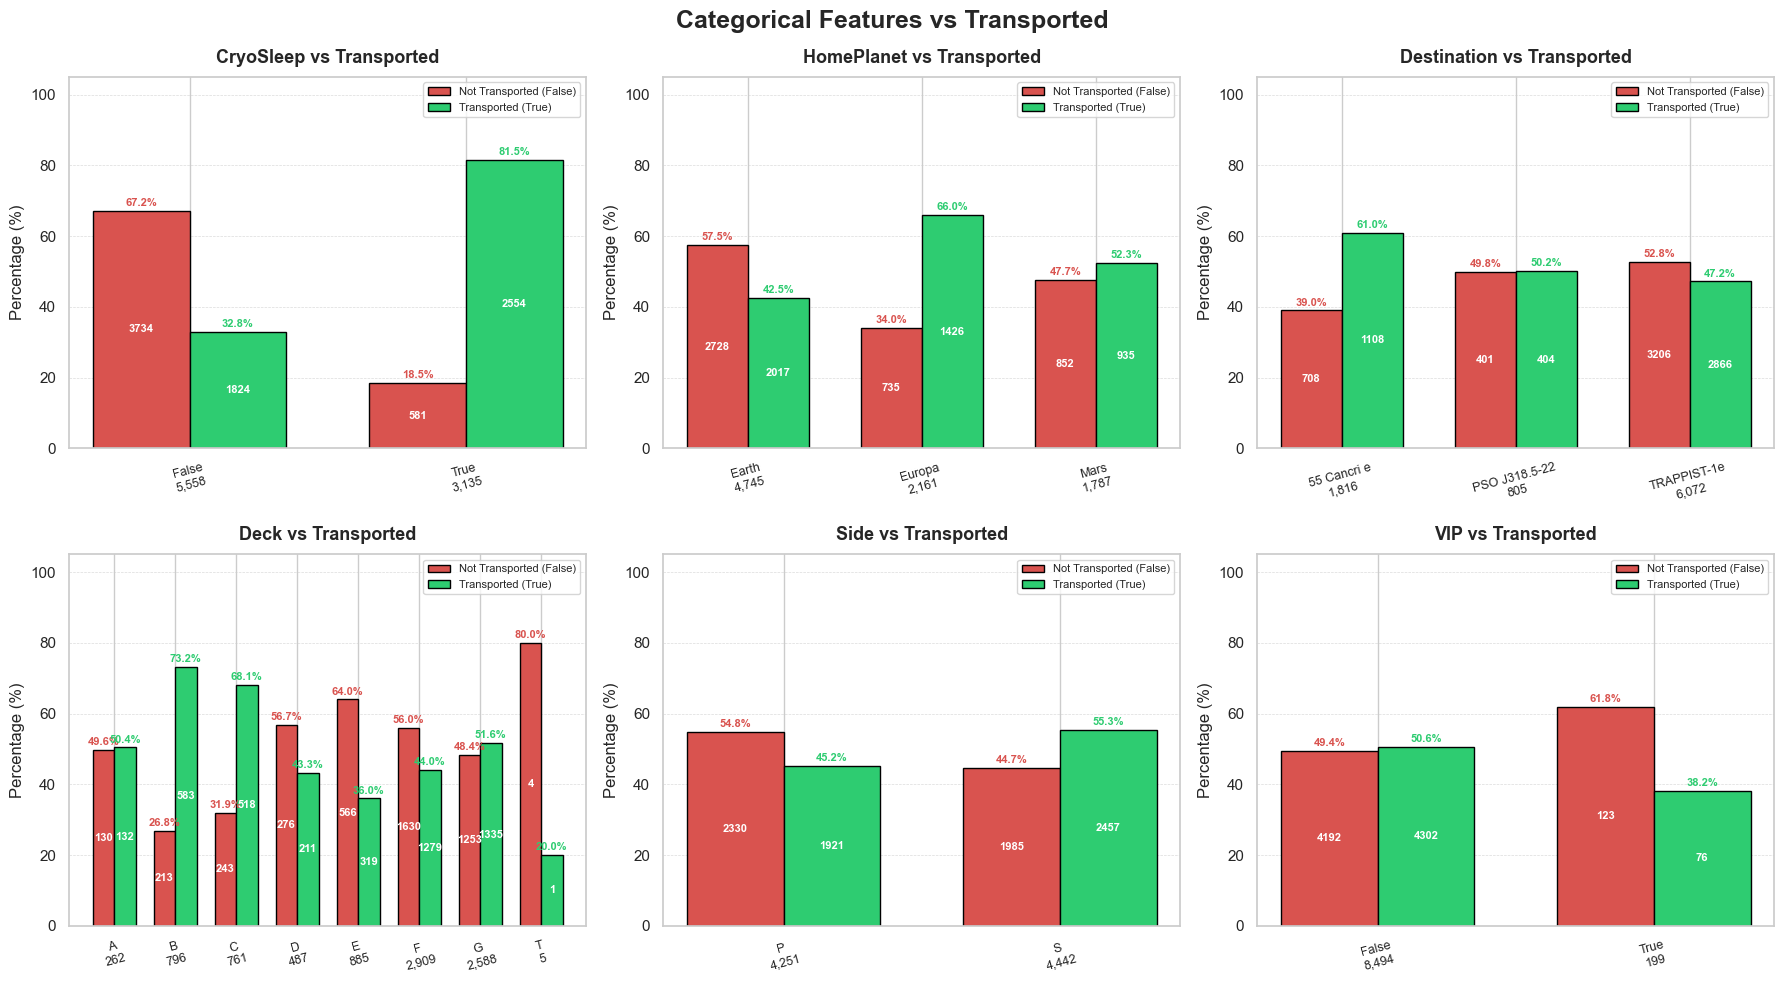

✅ Plot saved as eda_2b_categorical_features.png

=== Transported Rate per Categorical Feature ===

─────────────────────────────────────────────────────────────────
  📊 CryoSleep
─────────────────────────────────────────────────────────────────
 Category  Total  Transported Transported_%  Not_Transported Not_Transported_%
    False   5558         1824         32.8%             3734             67.2%
     True   3135         2554         81.5%              581             18.5%

─────────────────────────────────────────────────────────────────
  📊 HomePlanet
─────────────────────────────────────────────────────────────────
Category  Total  Transported Transported_%  Not_Transported Not_Transported_%
   Earth   4745         2017         42.5%             2728             57.5%
  Europa   2161         1426         66.0%              735             34.0%
    Mars   1787          935         52.3%              852             47.7%

─────────────────────────────────────────────────────────

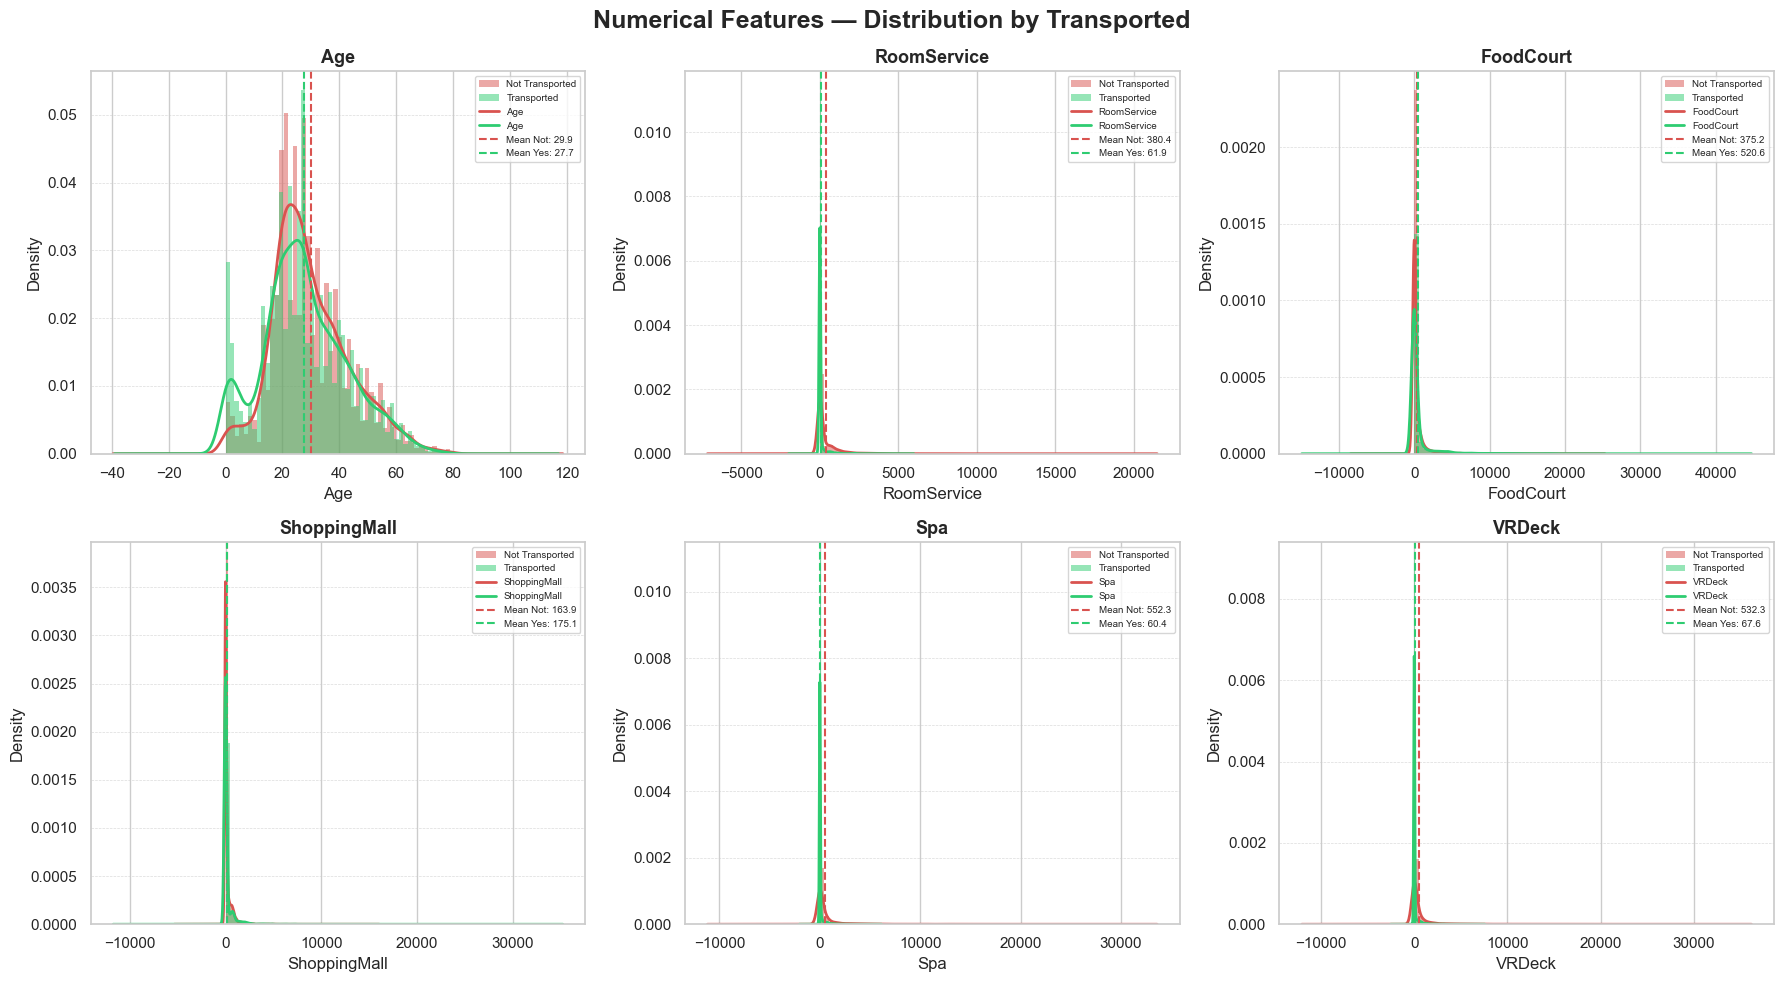

✅ Distribution plot saved

════════════════════════════════════════════════════════════
  📋 DISTRIBUTION SUMMARY — Mean & Median by Transported
════════════════════════════════════════════════════════════

───────────────────────────────────────────────────────
  📊 Age
───────────────────────────────────────────────────────
Metric Not Transported Transported Mean Gap
  Mean           29.86       27.73     2.13
Median           27.00       27.00        —

───────────────────────────────────────────────────────
  📊 RoomService
───────────────────────────────────────────────────────
Metric Not Transported Transported Mean Gap
  Mean          380.43       61.90   318.52
Median            1.00        0.00        —

───────────────────────────────────────────────────────
  📊 FoodCourt
───────────────────────────────────────────────────────
Metric Not Transported Transported Mean Gap
  Mean          375.17      520.65   145.48
Median            0.00        0.00        —

─────────────────────

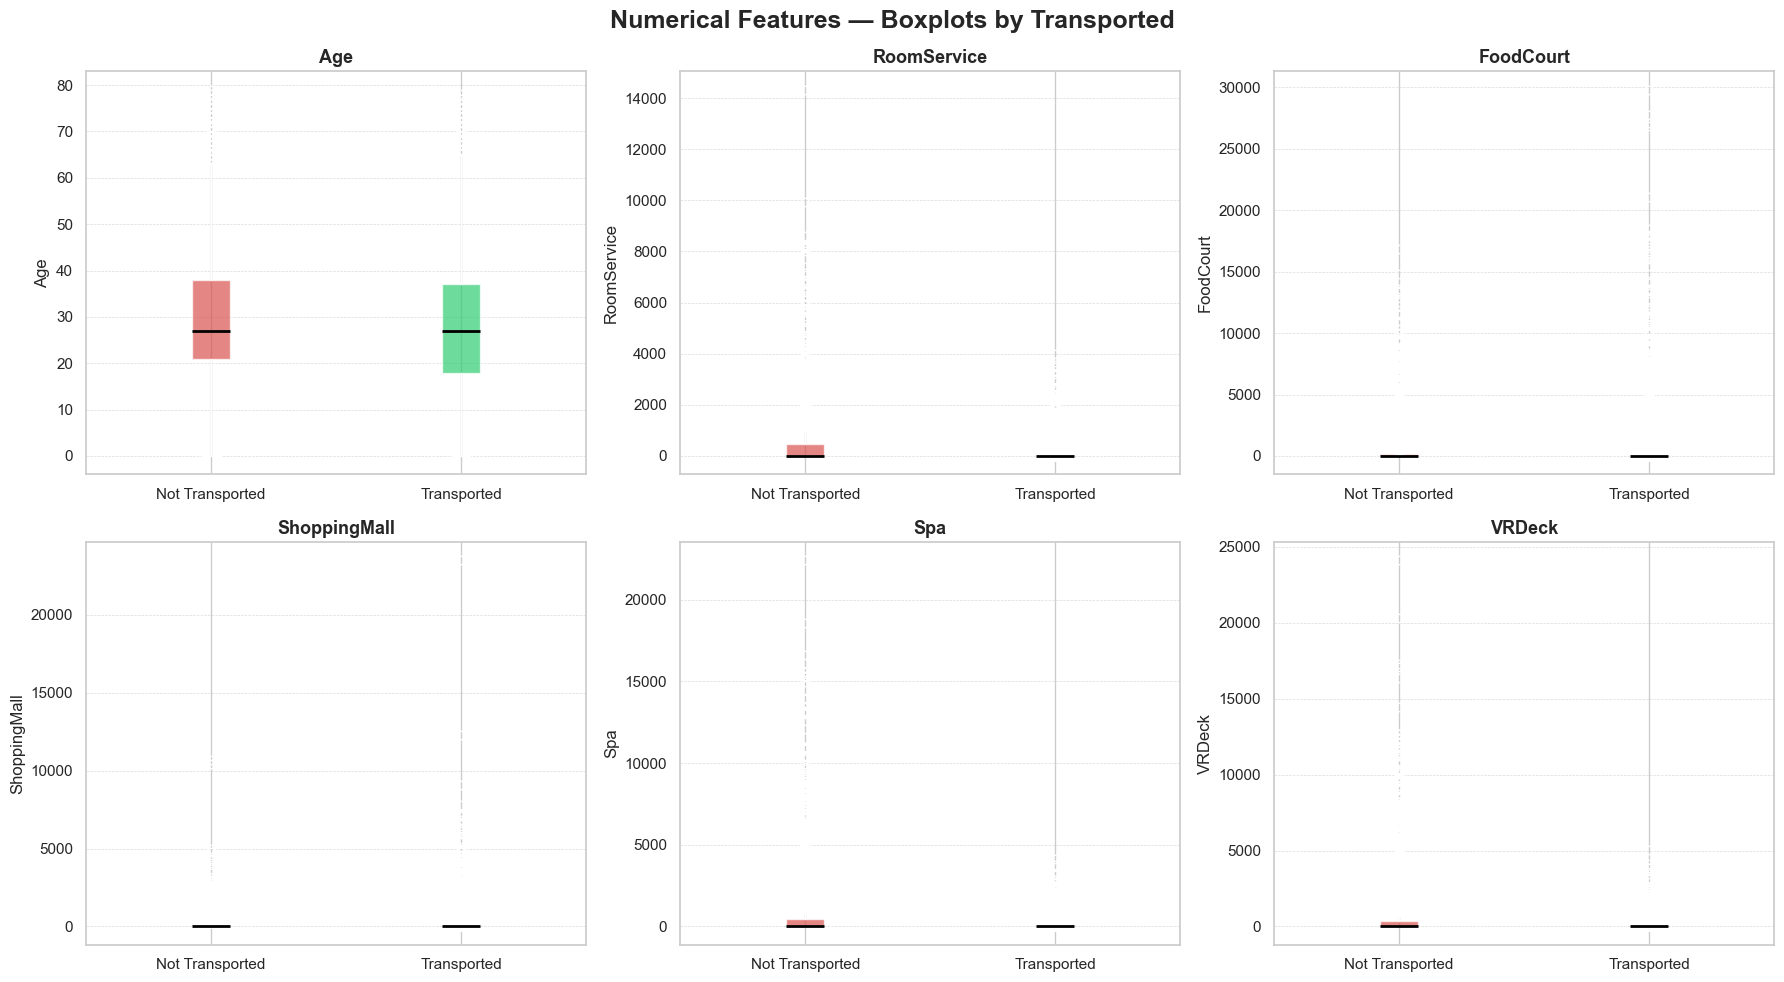

✅ Boxplot saved

═════════════════════════════════════════════════════════════════
  📋 BOXPLOT SUMMARY — Q1, Median, Q3, IQR by Transported
═════════════════════════════════════════════════════════════════

───────────────────────────────────────────────────────
  📊 Age
───────────────────────────────────────────────────────
      Metric Not Transported Transported
    Q1 (25%)           21.00       18.00
Median (50%)           27.00       27.00
    Q3 (75%)           38.00       37.00
         IQR           17.00       19.00
    Outliers              73          40

───────────────────────────────────────────────────────
  📊 RoomService
───────────────────────────────────────────────────────
      Metric Not Transported Transported
    Q1 (25%)            0.00        0.00
Median (50%)            1.00        0.00
    Q3 (75%)          454.00        0.00
         IQR          454.00        0.00
    Outliers             454         763

───────────────────────────────────────────────────

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


# ═══════════════════════════════════════════════════════════════════════
# 2A — TARGET VARIABLE ANALYSIS
# ═══════════════════════════════════════════════════════════════════════
def eda_target_variable(train):
    print("=== Transported Value Counts ===")
    print(train['Transported'].value_counts())

    print("\n=== Transported Percentage ===")
    print(train['Transported'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Target Variable — Transported', fontsize=16, fontweight='bold')

    counts = train['Transported'].value_counts()
    axes[0].bar(
        ['Not Transported\n(False)', 'Transported\n(True)'],
        counts.values, color=['#d9534f', '#2ecc71'], edgecolor='black', width=0.5
    )
    axes[0].set_title('Count of Each Class')
    axes[0].set_ylabel('Number of Passengers')
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold', fontsize=12)

    axes[1].pie(
        counts.values, labels=['Not Transported (False)', 'Transported (True)'],
        autopct='%1.2f%%', colors=['#d9534f', '#2ecc71'], startangle=90,
        wedgeprops={'edgecolor': 'black'}
    )
    axes[1].set_title('Class Distribution (%)')

    plt.tight_layout()
    plt.savefig('eda_2a_target_variable.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Plot saved as eda_2a_target_variable.png")


# ═══════════════════════════════════════════════════════════════════════
# 2B — CATEGORICAL FEATURES vs TRANSPORTED
# ═══════════════════════════════════════════════════════════════════════
def eda_categorical_features(train, categorical_cols=None):
    if categorical_cols is None:
        categorical_cols = ['CryoSleep', 'HomePlanet', 'Destination', 'Deck', 'Side', 'VIP']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Categorical Features vs Transported', fontsize=18, fontweight='bold')
    axes = axes.flatten()

    for i, col in enumerate(categorical_cols):
        ax = axes[i]

        summary = train.groupby(col)['Transported'].agg(
            Total='count', Transported_True='sum'
        ).reset_index()
        summary['Transported_False'] = summary['Total'] - summary['Transported_True']
        summary['Rate_True']  = (summary['Transported_True']  / summary['Total'] * 100).round(1)
        summary['Rate_False'] = (summary['Transported_False'] / summary['Total'] * 100).round(1)

        categories = summary[col].astype(str).tolist()
        x = np.arange(len(categories))
        bar_width = 0.35

        bars_false = ax.bar(x - bar_width/2, summary['Rate_False'], bar_width,
                             label='Not Transported (False)', color='#d9534f', edgecolor='black')
        bars_true  = ax.bar(x + bar_width/2, summary['Rate_True'], bar_width,
                             label='Transported (True)', color='#2ecc71', edgecolor='black')

        for bar in bars_false:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.8, f'{h:.1f}%',
                    ha='center', va='bottom', fontsize=8, fontweight='bold', color='#d9534f')
        for bar in bars_true:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.8, f'{h:.1f}%',
                    ha='center', va='bottom', fontsize=8, fontweight='bold', color='#2ecc71')

        for j, bar in enumerate(bars_false):
            count = summary['Transported_False'].values[j]
            if bar.get_height() > 5:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, str(count),
                        ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        for j, bar in enumerate(bars_true):
            count = summary['Transported_True'].values[j]
            if bar.get_height() > 5:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, str(count),
                        ha='center', va='center', fontsize=8, fontweight='bold', color='white')

        tick_labels = [
            f'{cat}\n{summary.loc[summary[col].astype(str)==cat, "Total"].values[0]:,}'
            for cat in categories
        ]
        ax.set_xticks(x)
        ax.set_xticklabels(tick_labels, fontsize=9, rotation=15)
        ax.set_title(f'{col} vs Transported', fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel('Percentage (%)')
        ax.set_ylim(0, 105)
        ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
        ax.set_axisbelow(True)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('eda_2b_categorical_features.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Plot saved as eda_2b_categorical_features.png")

    # ── Text summary tables ──
    print("\n=== Transported Rate per Categorical Feature ===\n")
    for col in categorical_cols:
        summary = train.groupby(col)['Transported'].agg(
            Total='count', Transported_True='sum'
        ).reset_index()
        summary['Not_Transported']   = summary['Total'] - summary['Transported_True']
        summary['Transported_%']     = (summary['Transported_True'] / summary['Total'] * 100).round(1).astype(str) + '%'
        summary['Not_Transported_%'] = (summary['Not_Transported']  / summary['Total'] * 100).round(1).astype(str) + '%'
        summary = summary.rename(columns={col: 'Category', 'Transported_True': 'Transported', 'Total': 'Total'})
        summary = summary[['Category', 'Total', 'Transported', 'Transported_%', 'Not_Transported', 'Not_Transported_%']]

        print(f"{'─'*65}\n  📊 {col}\n{'─'*65}")
        print(summary.to_string(index=False))
        print()


# ═══════════════════════════════════════════════════════════════════════
# 2C — NUMERICAL FEATURES: DISTRIBUTIONS + KDE
# ═══════════════════════════════════════════════════════════════════════
def eda_numerical_distributions(train, numerical_cols=None):
    if numerical_cols is None:
        numerical_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Numerical Features — Distribution by Transported', fontsize=18, fontweight='bold')
    axes = axes.flatten()

    for i, col in enumerate(numerical_cols):
        ax = axes[i]
        t_true  = train[train['Transported'] == True][col].dropna()
        t_false = train[train['Transported'] == False][col].dropna()

        ax.hist(t_false, bins=50, alpha=0.5, color='#d9534f', label='Not Transported', density=True, edgecolor='none')
        ax.hist(t_true,  bins=50, alpha=0.5, color='#2ecc71', label='Transported', density=True, edgecolor='none')

        t_false.plot.kde(ax=ax, color='#d9534f', linewidth=2)
        t_true.plot.kde(ax=ax,  color='#2ecc71', linewidth=2)

        ax.axvline(t_false.mean(), color='#d9534f', linestyle='--', linewidth=1.5, label=f'Mean Not: {t_false.mean():.1f}')
        ax.axvline(t_true.mean(),  color='#2ecc71', linestyle='--', linewidth=1.5, label=f'Mean Yes: {t_true.mean():.1f}')

        ax.set_title(f'{col}', fontsize=13, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Density')
        ax.legend(fontsize=7)
        ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
        ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig('eda_2c_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Distribution plot saved")

    print(f"\n{'═'*60}\n  📋 DISTRIBUTION SUMMARY — Mean & Median by Transported\n{'═'*60}\n")
    for col in numerical_cols:
        t_true  = train[train['Transported'] == True][col].dropna()
        t_false = train[train['Transported'] == False][col].dropna()

        summary = pd.DataFrame({
            'Metric': ['Mean', 'Median'],
            'Not Transported': [f"{t_false.mean():.2f}", f"{t_false.median():.2f}"],
            'Transported':     [f"{t_true.mean():.2f}",  f"{t_true.median():.2f}"],
            'Mean Gap':        [f"{abs(t_true.mean() - t_false.mean()):.2f}", '—']
        })
        print(f"{'─'*55}\n  📊 {col}\n{'─'*55}")
        print(summary.to_string(index=False))
        print()


# ═══════════════════════════════════════════════════════════════════════
# 2C — NUMERICAL FEATURES: BOXPLOTS
# ═══════════════════════════════════════════════════════════════════════
def eda_numerical_boxplots(train, numerical_cols=None):
    if numerical_cols is None:
        numerical_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    def count_outliers(series):
        Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
        IQR = Q3 - Q1
        return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Numerical Features — Boxplots by Transported', fontsize=18, fontweight='bold')
    axes = axes.flatten()

    for i, col in enumerate(numerical_cols):
        ax = axes[i]
        data_to_plot = [
            train[train['Transported'] == False][col].dropna().values,
            train[train['Transported'] == True][col].dropna().values
        ]
        bp = ax.boxplot(data_to_plot, patch_artist=True,
                         tick_labels=['Not Transported', 'Transported'],
                         medianprops=dict(color='black', linewidth=2))
        bp['boxes'][0].set_facecolor('#d9534f')
        bp['boxes'][1].set_facecolor('#2ecc71')
        for patch in bp['boxes']:
            patch.set_alpha(0.7)

        ax.set_title(f'{col}', fontsize=13, fontweight='bold')
        ax.set_ylabel(col)
        ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
        ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig('eda_2c_boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Boxplot saved")

    print(f"\n{'═'*65}\n  📋 BOXPLOT SUMMARY — Q1, Median, Q3, IQR by Transported\n{'═'*65}\n")
    for col in numerical_cols:
        t_true  = train[train['Transported'] == True][col].dropna()
        t_false = train[train['Transported'] == False][col].dropna()
        out_true, out_false = count_outliers(t_true), count_outliers(t_false)

        summary = pd.DataFrame({
            'Metric': ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)', 'IQR', 'Outliers'],
            'Not Transported': [
                f"{t_false.quantile(0.25):.2f}", f"{t_false.median():.2f}",
                f"{t_false.quantile(0.75):.2f}",
                f"{t_false.quantile(0.75) - t_false.quantile(0.25):.2f}", f"{out_false:,}"
            ],
            'Transported': [
                f"{t_true.quantile(0.25):.2f}", f"{t_true.median():.2f}",
                f"{t_true.quantile(0.75):.2f}",
                f"{t_true.quantile(0.75) - t_true.quantile(0.25):.2f}", f"{out_true:,}"
            ]
        })
        print(f"{'─'*55}\n  📊 {col}\n{'─'*55}")
        print(summary.to_string(index=False))
        print()


# ═══════════════════════════════════════════════════════════════════════
# MASTER FUNCTION — runs everything in sequence
# ═══════════════════════════════════════════════════════════════════════
def run_full_eda(train):
    print("\n" + "="*80)
    print(" RUNNING FULL EDA SUITE")
    print("="*80 + "\n")

    eda_target_variable(train)
    eda_categorical_features(train)
    eda_numerical_distributions(train)
    eda_numerical_boxplots(train)

    print("\n" + "="*80)
    print(" ✅ EDA COMPLETE — all plots saved to disk")
    print("="*80)


# ── Usage ──
train = pd.read_csv('train_clean.csv')
run_full_eda(train)


OUTLIER CAPPING (Winsorization)

In [22]:
# ═══════════════════════════════════════════════════════════════════════
# STEP 0 — OUTLIER CAPPING (Winsorization) — fit on TRAIN, apply to BOTH
# ═══════════════════════════════════════════════════════════════════════

def winsorize_columns(train_df, test_df, cols, lower_pct=0.01, upper_pct=0.99):
    train_df = train_df.copy()
    test_df  = test_df.copy()
    bounds = {}

    for col in cols:
        lower = train_df[col].quantile(lower_pct)
        upper = train_df[col].quantile(upper_pct)
        bounds[col] = (lower, upper)

        train_df[col] = train_df[col].clip(lower=lower, upper=upper)
        test_df[col]  = test_df[col].clip(lower=lower, upper=upper)

        print(f"✅ {col:15s} capped to [{lower:8.2f}, {upper:8.2f}]")

    return train_df, test_df, bounds


train = pd.read_csv('train_clean.csv')
test  = pd.read_csv('test_clean.csv')

spending_cols_to_cap = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Age']

train, test, winsor_bounds = winsorize_columns(train, test, spending_cols_to_cap, 0.01, 0.99)

print(f"\nTrain shape after capping: {train.shape}")
print(f"Test  shape after capping: {test.shape}")

✅ RoomService     capped to [    0.00,  3087.24]
✅ FoodCourt       capped to [    0.00,  7992.32]
✅ ShoppingMall    capped to [    0.00,  2317.12]
✅ Spa             capped to [    0.00,  5294.52]
✅ VRDeck          capped to [    0.00,  5567.16]
✅ Age             capped to [    0.00,    65.00]

Train shape after capping: (8693, 18)
Test  shape after capping: (4277, 17)


FEATURE ENGINEERING

✅ Feature engineering applied!
   Train shape: (8693, 31)
   Test  shape: (4277, 30)

✅ CabinDeck encoded — 8 categories found in train
✅ CabinSide encoded — 2 categories found in train
✅ AgeGroup encoded — 5 categories found in train
✅ Route encoded — 9 categories found in train
✅ Planet_Cryo encoded — 6 categories found in train

📊 Feature Correlation vs Target (ranked by strength):

Planet_Cryo_int    0.492513
IsZeroSpender      0.481628
CryoSleep          0.467230
LuxurySpend       -0.348244
RoomService       -0.241124
Spa               -0.218545
Route_int          0.210683
VRDeck            -0.204874
TotalSpend        -0.199514
CabinDeck_int      0.199148
IsAlone           -0.113792
AgeGroup_int       0.109097
CabinSide_int      0.101214
GroupSize          0.082644
Age               -0.074233
NonLuxurySpend     0.046189
FoodCourt          0.045583
RoomNumber        -0.044502
CabinNum          -0.044502
VIP               -0.037261
Group              0.021491
ShoppingMall       0.00

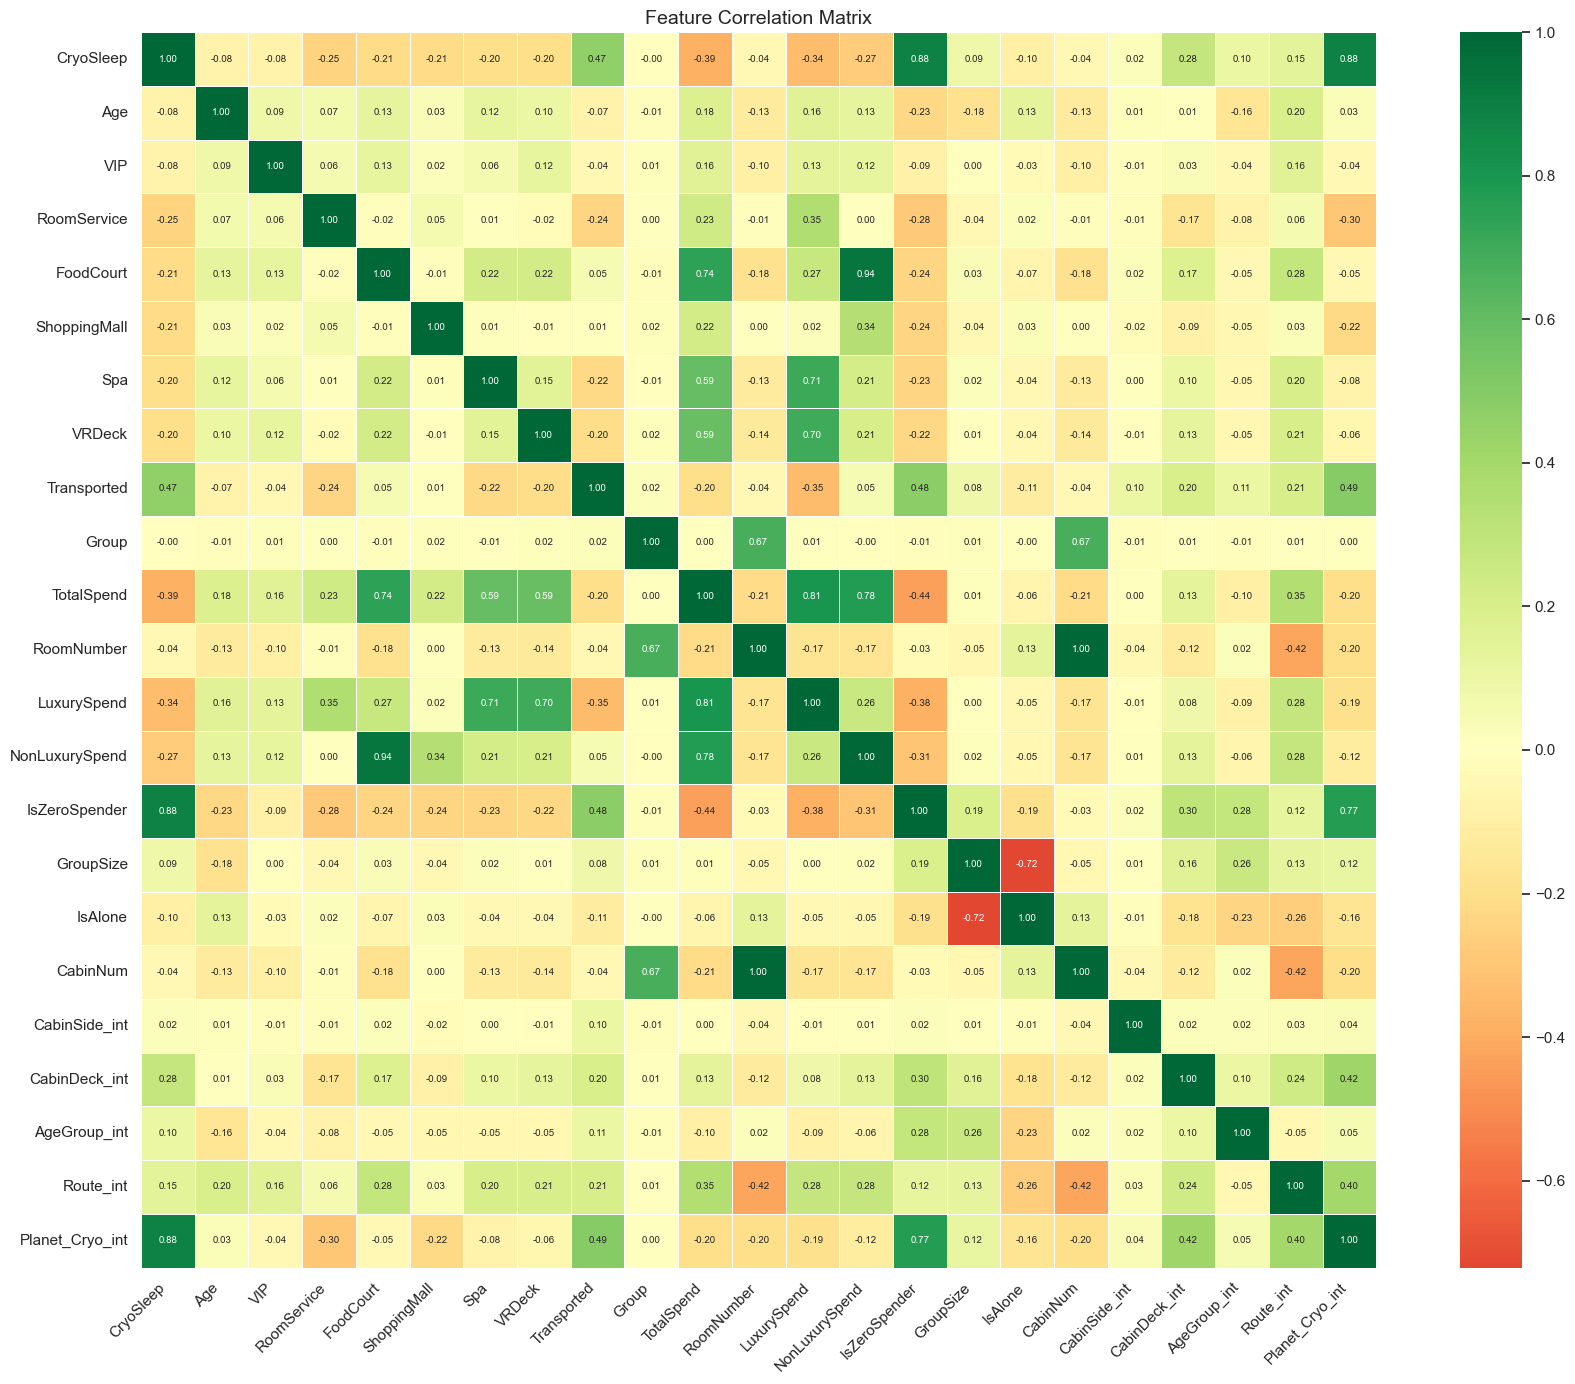


✅ Dropped RoomNumber (duplicate of CabinNum)
   Final train shape: (8693, 34)
   Final test  shape: (4277, 33)

💾 Saved checkpoint files:
   train_features.csv  (8693 rows, 34 cols)
   test_features.csv   (4277 rows, 33 cols)


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ═══════════════════════════════════════════════════════════════════════
# STEP 1 — FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════════════════

def engineer_features(df, is_train=True):
    df = df.copy()

    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['TotalSpend'] = df[spending_cols].sum(axis=1)

    df['LuxurySpend']    = df['RoomService'] + df['Spa'] + df['VRDeck']
    df['NonLuxurySpend'] = df['FoodCourt'] + df['ShoppingMall']

    df['IsZeroSpender'] = (df['TotalSpend'] == 0).astype(int)

    df['GroupId']   = df['PassengerId'].str.split('_').str[0]
    df['GroupSize'] = df.groupby('GroupId')['PassengerId'].transform('count')
    df['IsAlone']   = (df['GroupSize'] == 1).astype(int)

    df[['CabinDeck', 'CabinNum', 'CabinSide']] = df['Cabin'].str.split('/', expand=True)
    df['CabinNum']      = pd.to_numeric(df['CabinNum'], errors='coerce')
    df['CabinSide_int'] = (df['CabinSide'] == 'S').astype(int)

    age_bins   = [0, 12, 17, 35, 60, 100]
    age_labels = ['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']
    df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, include_lowest=True)

    df['Route'] = df['HomePlanet'] + '_' + df['Destination']
    df['Planet_Cryo'] = df['HomePlanet'] + '_' + df['CryoSleep'].astype(str)

    return df


# ═══════════════════════════════════════════════════════════════════════
# STEP 2 — LEAK-SAFE RANK ENCODING (fit on train, apply to both)
# ═══════════════════════════════════════════════════════════════════════

def fit_rank_encoding(train_df, col, target='Transported'):
    rate_order = train_df.groupby(col, observed=True)[target].mean().sort_values().index
    return {category: rank for rank, category in enumerate(rate_order)}


def apply_rank_encoding(df, col, mapping, fallback=None):
    if fallback is None:
        fallback = np.median(list(mapping.values()))
    mapped = df[col].astype(str).map({str(k): v for k, v in mapping.items()})
    return mapped.fillna(fallback).astype(float)


def encode_categoricals(train_df, test_df, cols, target='Transported'):
    encoding_maps = {}
    for col in cols:
        mapping = fit_rank_encoding(train_df, col, target=target)
        encoding_maps[col] = mapping

        train_df[col + '_int'] = apply_rank_encoding(train_df, col, mapping)
        test_df[col + '_int']  = apply_rank_encoding(test_df,  col, mapping)

        print(f"✅ {col} encoded — {len(mapping)} categories found in train")

    return train_df, test_df, encoding_maps


# ═══════════════════════════════════════════════════════════════════════
# STEP 3 — CORRELATION SUMMARY (TEXT RANKING + HEATMAP)
# ═══════════════════════════════════════════════════════════════════════

def get_correlation_summary(df, target='Transported', show_heatmap=True):
    numeric_df = df.select_dtypes(include=['int64', 'float64', 'bool']).copy()

    if numeric_df[target].dtype == 'bool':
        numeric_df[target] = numeric_df[target].astype(int)

    corr_matrix = numeric_df.corr()

    target_corr = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)
    print("\n📊 Feature Correlation vs Target (ranked by strength):\n")
    print(target_corr)

    print("\n⚠️  High Intercorrelation Pairs (|corr| > 0.7, excluding target):\n")
    corr_pairs = corr_matrix.drop(index=target, columns=target).unstack()
    corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
    corr_pairs = corr_pairs[abs(corr_pairs) > 0.7].sort_values(key=abs, ascending=False)

    seen = set()
    for (a, b), val in corr_pairs.items():
        pair = tuple(sorted([a, b]))
        if pair not in seen:
            seen.add(pair)
            print(f"  {a:20s} ↔ {b:20s}  {val:+.4f}")

    if show_heatmap:
        plt.figure(figsize=(18, 14))
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
                    center=0, square=True, linewidths=0.5,
                    annot_kws={"size": 7})
        plt.title('Feature Correlation Matrix', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    return corr_matrix, target_corr


# ═══════════════════════════════════════════════════════════════════════
# STEP 4 — DROP TRUE DUPLICATE ONLY (RoomNumber == CabinNum, corr = +1.0)
# ═══════════════════════════════════════════════════════════════════════

def select_final_features(df, drop_cols=None):
    """
    Minimal, safe trimming — only removes exact duplicate columns.
    Everything else is kept for the model to decide on its own.
    """
    if drop_cols is None:
        drop_cols = ['RoomNumber']  # exact duplicate of CabinNum

    return df.drop(columns=[c for c in drop_cols if c in df.columns])


# ═══════════════════════════════════════════════════════════════════════
# RUN THE FULL PIPELINE
# ═══════════════════════════════════════════════════════════════════════

train = pd.read_csv('train_clean.csv')
test  = pd.read_csv('test_clean.csv')

train = engineer_features(train, is_train=True)
test  = engineer_features(test,  is_train=False)

print(f"✅ Feature engineering applied!")
print(f"   Train shape: {train.shape}")
print(f"   Test  shape: {test.shape}\n")

cols_to_encode = ['CabinDeck', 'CabinSide', 'AgeGroup', 'Route', 'Planet_Cryo']
train, test, encoding_maps = encode_categoricals(train, test, cols_to_encode, target='Transported')

corr_matrix, target_corr = get_correlation_summary(train, target='Transported', show_heatmap=True)

# Drop RoomNumber (exact duplicate of CabinNum) from both sets
train = select_final_features(train)
test  = select_final_features(test)

print(f"\n✅ Dropped RoomNumber (duplicate of CabinNum)")
print(f"   Final train shape: {train.shape}")
print(f"   Final test  shape: {test.shape}")

# ═══════════════════════════════════════════════════════════════════════
# SAVE CHECKPOINT — engineered features, ready for the next steps
# ═══════════════════════════════════════════════════════════════════════

train.to_csv('train_features.csv', index=False)
test.to_csv('test_features.csv', index=False)

print(f"\n💾 Saved checkpoint files:")
print(f"   train_features.csv  ({train.shape[0]} rows, {train.shape[1]} cols)")
print(f"   test_features.csv   ({test.shape[0]} rows, {test.shape[1]} cols)")

ENCODING LEFTOVER CATEGORICAL

In [24]:
import numpy as np

def fit_rank_encoding(train_df, col, target='Transported'):
    """Fit a rank encoding: maps each category to its rank by mean target rate."""
    rate_order = train_df.groupby(col, observed=True)[target].mean().sort_values().index
    return {category: rank for rank, category in enumerate(rate_order)}


def apply_rank_encoding(df, col, mapping, fallback=None):
    """Apply a fitted rank encoding to a dataframe column."""
    if fallback is None:
        fallback = np.median(list(mapping.values()))
    mapped = df[col].astype(str).map({str(k): v for k, v in mapping.items()})
    return mapped.fillna(fallback).astype(float)


def encode_leftovers(train_df, test_df, target='Transported'):
    """
    Encodes the remaining raw categorical columns (HomePlanet, Destination)
    using leak-safe rank encoding (fit on train, applied to both), converts
    boolean columns to int, and drops the now-redundant raw string columns.
    """
    train_df = train_df.copy()
    test_df  = test_df.copy()

    encoding_maps = {}
    leftover_cols = ['HomePlanet', 'Destination']

    # Rank-encode leftover categorical columns
    for col in leftover_cols:
        mapping = fit_rank_encoding(train_df, col, target=target)
        encoding_maps[col] = mapping

        train_df[col + '_int'] = apply_rank_encoding(train_df, col, mapping)
        test_df[col + '_int']  = apply_rank_encoding(test_df,  col, mapping)

        print(f"✅ {col} encoded — {len(mapping)} categories found in train")

    # Convert boolean columns to int (0/1)
    for col in ['CryoSleep', 'VIP']:
        train_df[col] = train_df[col].astype(int)
        test_df[col]  = test_df[col].astype(int)
        print(f"✅ {col} converted to int")

    # Convert target to int (train only — test doesn't have this column)
    train_df[target] = train_df[target].astype(int)
    print(f"✅ {target} converted to int")

    # Drop the now-redundant raw string columns
    train_df = train_df.drop(columns=leftover_cols)
    test_df  = test_df.drop(columns=leftover_cols)

    print(f"\n✅ Final train shape: {train_df.shape}")
    print(f"✅ Final test  shape: {test_df.shape}")

    return train_df, test_df, encoding_maps


# Run it
train, test, leftover_encoding_maps = encode_leftovers(train, test, target='Transported')

print("\n═══ Final dtypes ═══")
print(train.dtypes)

print("\n═══ Any remaining non-numeric columns? ═══")
non_numeric = train.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
print(non_numeric if non_numeric else "None — fully numeric! ✅")


✅ HomePlanet encoded — 3 categories found in train
✅ Destination encoded — 3 categories found in train
✅ CryoSleep converted to int
✅ VIP converted to int
✅ Transported converted to int

✅ Final train shape: (8693, 34)
✅ Final test  shape: (4277, 33)

═══ Final dtypes ═══
PassengerId          object
CryoSleep             int64
Cabin                object
Age                 float64
VIP                   int64
RoomService         float64
FoodCourt           float64
ShoppingMall        float64
Spa                 float64
VRDeck              float64
Transported           int64
Group                 int64
TotalSpend          float64
Deck                 object
Side                 object
LuxurySpend         float64
NonLuxurySpend      float64
IsZeroSpender         int64
GroupId              object
GroupSize             int64
IsAlone               int64
CabinDeck            object
CabinNum            float64
CabinSide            object
CabinSide_int       float64
AgeGroup           category

DROP COLUMNS

In [25]:
def cleanup_columns(train_df, test_df):
    drop_cols = [
        'PassengerId',
        'Cabin',
        'GroupId',
        'Deck',
        'Side',
        'CabinDeck',
        'CabinSide',
        'AgeGroup',
        'Route',
        'Planet_Cryo',
    ]

    train_df = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
    test_df  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

    print(f"✅ Dropped columns: {[c for c in drop_cols if c in train.columns]}")
    print(f"   Train shape: {train_df.shape}")
    print(f"   Test  shape: {test_df.shape}")

    return train_df, test_df


train, test = cleanup_columns(train, test)
print("\nRemaining columns:", train.columns.tolist())
non_numeric = train.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
print(non_numeric if non_numeric else "None — fully numeric! ✅")

✅ Dropped columns: ['PassengerId', 'Cabin', 'GroupId', 'Deck', 'Side', 'CabinDeck', 'CabinSide', 'AgeGroup', 'Route', 'Planet_Cryo']
   Train shape: (8693, 24)
   Test  shape: (4277, 23)

Remaining columns: ['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'Group', 'TotalSpend', 'LuxurySpend', 'NonLuxurySpend', 'IsZeroSpender', 'GroupSize', 'IsAlone', 'CabinNum', 'CabinSide_int', 'CabinDeck_int', 'AgeGroup_int', 'Route_int', 'Planet_Cryo_int', 'HomePlanet_int', 'Destination_int']
None — fully numeric! ✅


VIF/multicollinearity heatmap

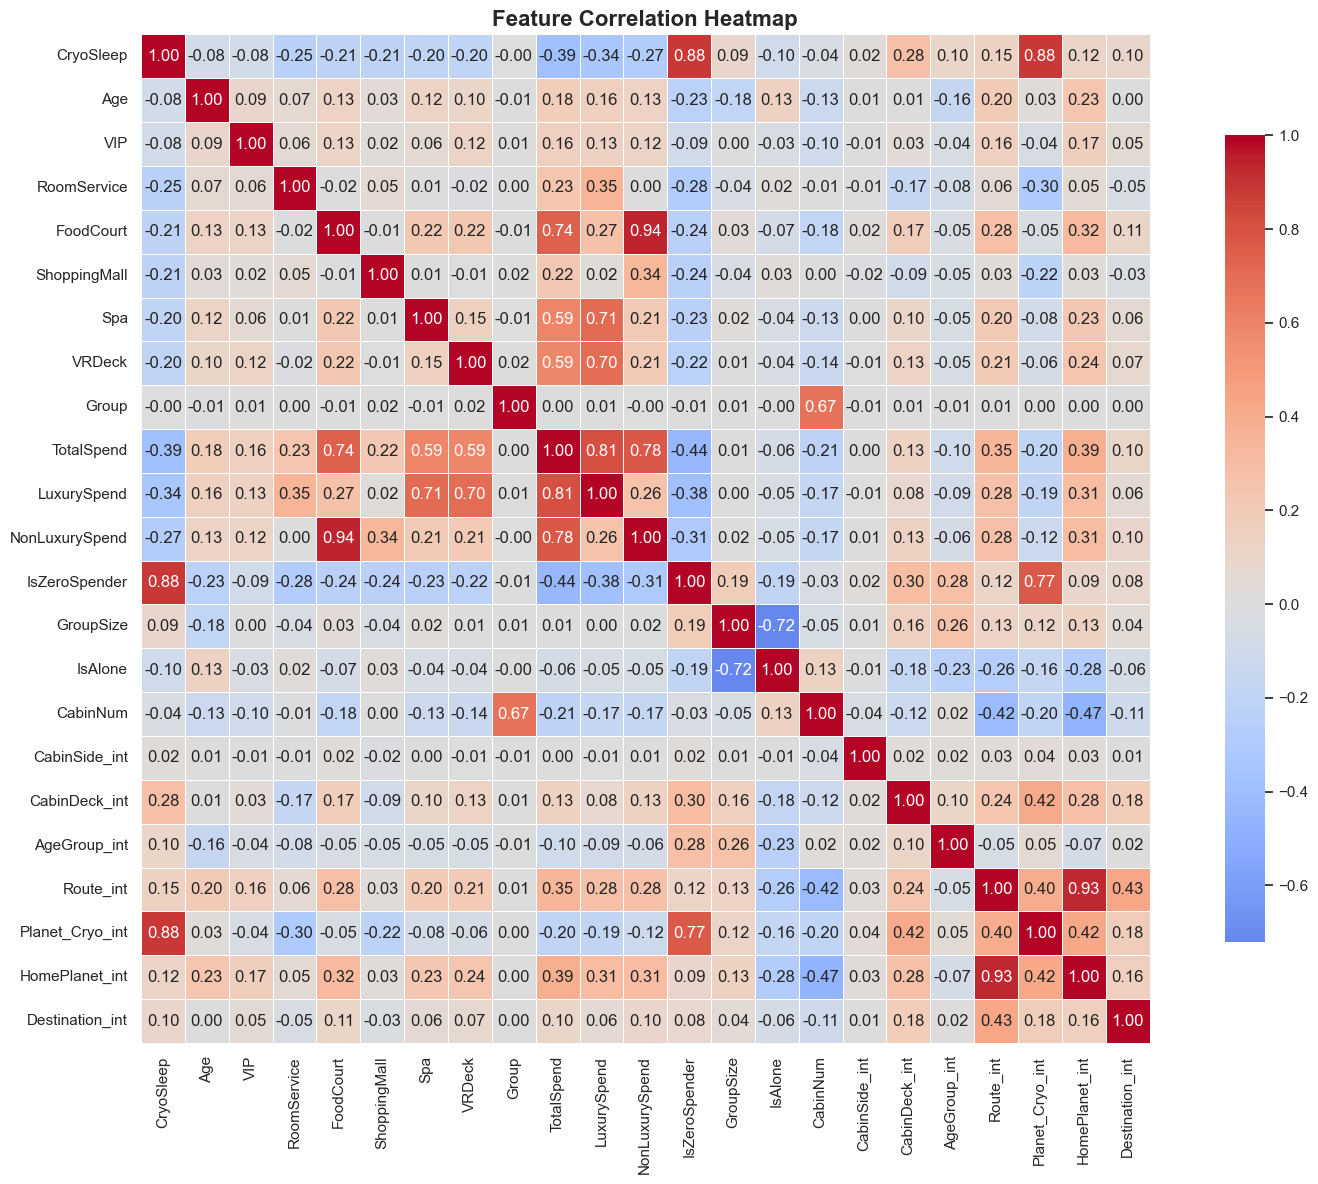

C:\Users\AMURUG15\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


══════════════════════════════════════════════════
VARIANCE INFLATION FACTOR (VIF) TABLE
══════════════════════════════════════════════════
        Feature       VIF     Status
   ShoppingMall       inf 🔴 INFINITE
      FoodCourt       inf 🔴 INFINITE
    RoomService       inf 🔴 INFINITE
            Spa       inf 🔴 INFINITE
    LuxurySpend       inf 🔴 INFINITE
     TotalSpend       inf 🔴 INFINITE
         VRDeck       inf 🔴 INFINITE
 NonLuxurySpend       inf 🔴 INFINITE
      Route_int 44.988143   🔴 Severe
 HomePlanet_int 39.590988   🔴 Severe
Planet_Cryo_int 30.097844   🔴 Severe
      CryoSleep 19.868896   🔴 Severe
  IsZeroSpender 11.515350   🔴 Severe
          Group  9.687295 🟠 Moderate
  CabinDeck_int  8.227485 🟠 Moderate
       CabinNum  7.557203 🟠 Moderate
            Age  5.373215 🟠 Moderate
Destination_int  4.166107       ✅ OK
      GroupSize  4.156349       ✅ OK
        IsAlone  3.520471       ✅ OK
   AgeGroup_int  2.187886       ✅ OK
  CabinSide_int  1.993358       ✅ OK
         

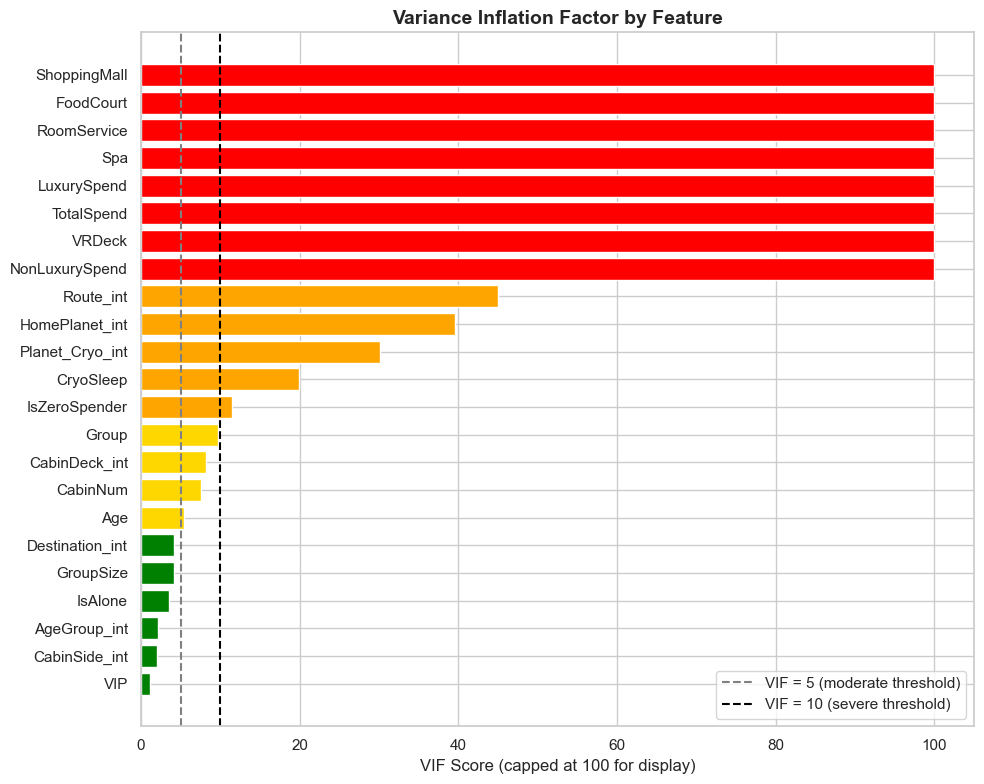

In [26]:
# ═══════════════════════════════════════════════════════════════════════
# MULTICOLLINEARITY VISUALIZATION — Heatmap + VIF Table
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ─── 1) Correlation Heatmap ───
X_check = train.drop(columns=['Transported'])
corr_matrix = X_check.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── 2) VIF Table (styled) ───
vif_data = pd.DataFrame()
vif_data['Feature'] = X_check.columns
vif_data['VIF'] = [variance_inflation_factor(X_check.values, i) for i in range(X_check.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

def flag_vif(v):
    if v == float('inf'):
        return '🔴 INFINITE'
    elif v > 10:
        return '🔴 Severe'
    elif v > 5:
        return '🟠 Moderate'
    else:
        return '✅ OK'

vif_data['Status'] = vif_data['VIF'].apply(flag_vif)

print("═" * 50)
print("VARIANCE INFLATION FACTOR (VIF) TABLE")
print("═" * 50)
print(vif_data.to_string(index=False))
print("═" * 50)

# Optional: bar chart of VIF scores (capped for visibility since some are inf)
vif_plot = vif_data.copy()
vif_plot['VIF_capped'] = vif_plot['VIF'].replace(float('inf'), 100)  # cap for plotting

plt.figure(figsize=(10, 8))
colors = ['red' if v == float('inf') else ('orange' if v > 10 else ('gold' if v > 5 else 'green'))
          for v in vif_plot['VIF']]
plt.barh(vif_plot['Feature'], vif_plot['VIF_capped'], color=colors)
plt.axvline(x=5, color='gray', linestyle='--', label='VIF = 5 (moderate threshold)')
plt.axvline(x=10, color='black', linestyle='--', label='VIF = 10 (severe threshold)')
plt.xlabel('VIF Score (capped at 100 for display)')
plt.title('Variance Inflation Factor by Feature', fontsize=14, fontweight='bold')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


LOGISTIC REGRESSION

Original train shape (untouched): (8693, 24)
Logistic regression feature set:  (8693, 18)  (dropped 5 redundant columns)

Training Logistic Regression...

Accuracy : 0.7884

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.79      0.78      0.79       863
    Transported       0.79      0.79      0.79       876

       accuracy                           0.79      1739
      macro avg       0.79      0.79      0.79      1739
   weighted avg       0.79      0.79      0.79      1739

WHAT MODEL PREDICTED vs REALITY
✅ NOT Transported & Said NOT : 675
❌ NOT Transported & Said YES : 188
❌ Transported     & Said NOT : 180
✅ Transported     & Said YES : 696


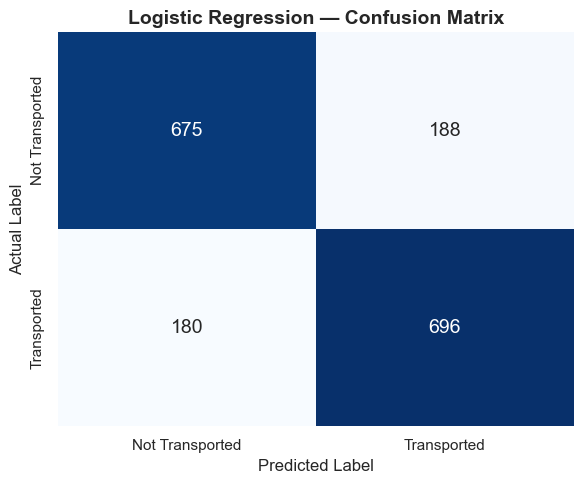

In [27]:
# ═══════════════════════════════════════════════════════════════════════
# MODEL 1 — LOGISTIC REGRESSION
# (Uses a SEPARATE pruned copy of the data — original `train` is untouched)
# ═══════════════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── Create a separate feature set JUST for this model ──
cols_to_drop_for_linear = ['TotalSpend', 'LuxurySpend', 'NonLuxurySpend', 'Route_int', 'Planet_Cryo_int']

X_linear = train.drop(columns=['Transported'] + cols_to_drop_for_linear)  # separate copy, train untouched
y = train['Transported']

print(f"Original train shape (untouched): {train.shape}")
print(f"Logistic regression feature set:  {X_linear.shape}  (dropped {len(cols_to_drop_for_linear)} redundant columns)\n")

# ── Train/validation split ──
X_train, X_val, y_train, y_val = train_test_split(
    X_linear, y, test_size=0.2, random_state=42, stratify=y
)

# ── Scale features (required for logistic regression) ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# ── Train model ──
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# ── Predict ──
preds = log_model.predict(X_val_scaled)

# ── Detailed output ──
acc = accuracy_score(y_val, preds)

print("Training Logistic Regression...")
print(f"\nAccuracy : {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, preds, target_names=['Not Transported', 'Transported']))

tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()

print("=======================================================")
print("WHAT MODEL PREDICTED vs REALITY")
print("=======================================================")
print(f"✅ NOT Transported & Said NOT : {tn}")
print(f"❌ NOT Transported & Said YES : {fp}")
print(f"❌ Transported     & Said NOT : {fn}")
print(f"✅ Transported     & Said YES : {tp}")
print("=======================================================")

# ── Confusion Matrix — Visual ──
cm = confusion_matrix(y_val, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Transported', 'Transported'],
    yticklabels=['Not Transported', 'Transported'],
    cbar=False,
    annot_kws={"size": 14}
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('Logistic Regression — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Store result for later comparison table ──
report_dict = classification_report(y_val, preds, target_names=['Not Transported', 'Transported'], output_dict=True)

model_results = {}  # fresh tracker — will keep growing as we add more models
model_results["Logistic Regression"] = {
    'accuracy': acc,
    'precision_0': report_dict['Not Transported']['precision'],
    'precision_1': report_dict['Transported']['precision'],
    'recall_0': report_dict['Not Transported']['recall'],
    'recall_1': report_dict['Transported']['recall'],
    'f1_0': report_dict['Not Transported']['f1-score'],
    'f1_1': report_dict['Transported']['f1-score'],
    'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    'total_right': tn + tp,
    'total_wrong': fp + fn
}


LASSO REGRESSION

Lasso feature set: (8693, 23)  (using ALL columns — no manual drops)

✅ Best C (regularization strength): 0.08685

Training Lasso Logistic Regression...

Accuracy : 0.7884

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.79      0.78      0.79       863
    Transported       0.79      0.79      0.79       876

       accuracy                           0.79      1739
      macro avg       0.79      0.79      0.79      1739
   weighted avg       0.79      0.79      0.79      1739

WHAT MODEL PREDICTED vs REALITY
✅ NOT Transported & Said NOT : 677
❌ NOT Transported & Said YES : 186
❌ Transported     & Said NOT : 182
✅ Transported     & Said YES : 694


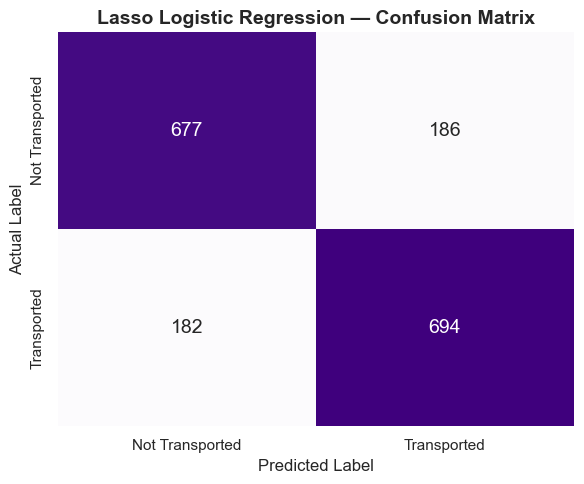


════════════════════════════════════════════════════════════
LASSO COEFFICIENTS — Feature Importance & Elimination
════════════════════════════════════════════════════════════
        Feature  Coefficient  Abs_Coefficient       Status
    LuxurySpend    -2.064683         2.064683       ✅ Kept
Planet_Cryo_int     0.929483         0.929483       ✅ Kept
 NonLuxurySpend     0.781544         0.781544       ✅ Kept
            Spa    -0.560758         0.560758       ✅ Kept
 HomePlanet_int     0.345288         0.345288       ✅ Kept
         VRDeck    -0.316176         0.316176       ✅ Kept
  CabinSide_int     0.245879         0.245879       ✅ Kept
      Route_int     0.243548         0.243548       ✅ Kept
  IsZeroSpender     0.156887         0.156887       ✅ Kept
      CryoSleep    -0.144959         0.144959       ✅ Kept
       CabinNum     0.142351         0.142351       ✅ Kept
   ShoppingMall     0.100810         0.100810       ✅ Kept
            Age    -0.089543         0.089543       ✅ Ke

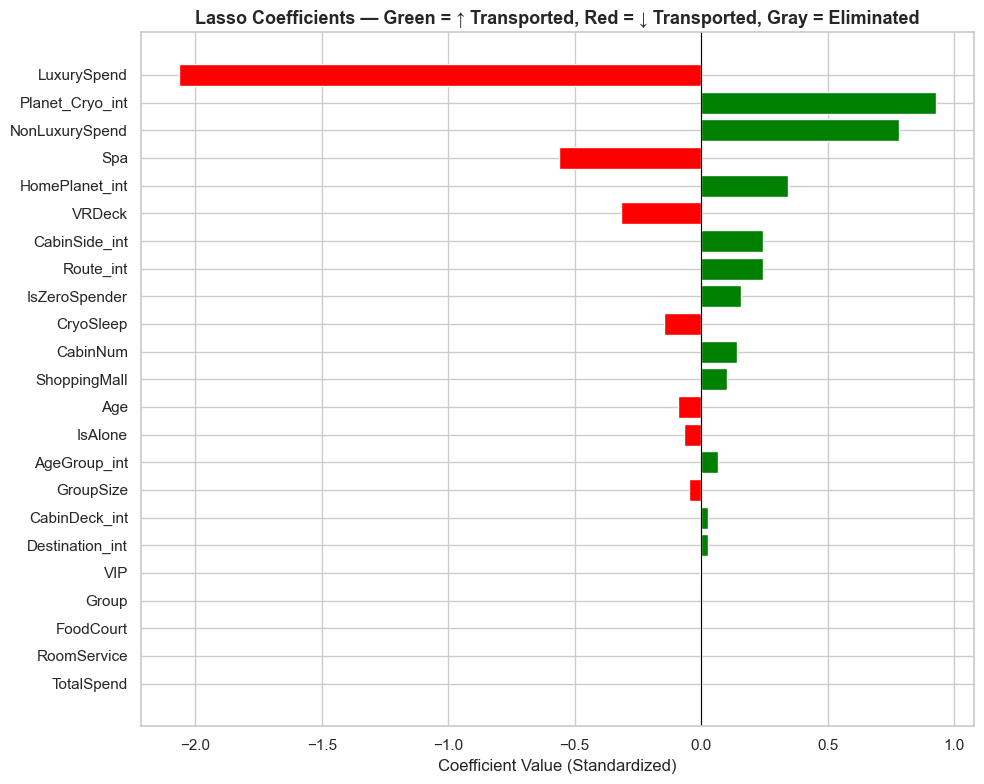


════════════════════════════════════════════════════════════
MODEL COMPARISON SO FAR
════════════════════════════════════════════════════════════
Logistic Regression             Accuracy: 0.7884
Lasso Logistic Regression       Accuracy: 0.7884
════════════════════════════════════════════════════════════


In [28]:
# ═══════════════════════════════════════════════════════════════════════
# MODEL 2 — LASSO (L1-REGULARIZED LOGISTIC REGRESSION)
# Uses the FULL feature set (including the redundant columns we manually
# dropped for plain Logistic Regression) — let Lasso decide what to keep
# ═══════════════════════════════════════════════════════════════════════

from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── Full feature set (NO manual dropping this time) ──
X_full = train.drop(columns=['Transported'])
y = train['Transported']

print(f"Lasso feature set: {X_full.shape}  (using ALL columns — no manual drops)\n")

# ── Train/validation split (same random_state so comparisons are fair) ──
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# ── Scale features (required — L1 penalty is scale-sensitive) ──
scaler_lasso = StandardScaler()
X_train_scaled = scaler_lasso.fit_transform(X_train)
X_val_scaled   = scaler_lasso.transform(X_val)

# ── Train Lasso Logistic Regression with cross-validated C ──
# Cs = inverse of regularization strength; more values tested here for finer search
lasso_model = LogisticRegressionCV(
    Cs=np.logspace(-4, 2, 50),   # search 50 values from 0.0001 to 100
    cv=5,
    penalty='l1',
    solver='liblinear',          # required solver for l1 penalty
    scoring='accuracy',
    max_iter=5000,
    random_state=42
)
lasso_model.fit(X_train_scaled, y_train)

print(f"✅ Best C (regularization strength): {lasso_model.C_[0]:.5f}\n")

# ── Predict ──
preds_lasso = lasso_model.predict(X_val_scaled)
acc_lasso = accuracy_score(y_val, preds_lasso)

print("Training Lasso Logistic Regression...")
print(f"\nAccuracy : {acc_lasso:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, preds_lasso, target_names=['Not Transported', 'Transported']))

tn, fp, fn, tp = confusion_matrix(y_val, preds_lasso).ravel()

print("=======================================================")
print("WHAT MODEL PREDICTED vs REALITY")
print("=======================================================")
print(f"✅ NOT Transported & Said NOT : {tn}")
print(f"❌ NOT Transported & Said YES : {fp}")
print(f"❌ Transported     & Said NOT : {fn}")
print(f"✅ Transported     & Said YES : {tp}")
print("=======================================================")

# ── Confusion Matrix — Visual ──
cm_lasso = confusion_matrix(y_val, preds_lasso)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lasso,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Not Transported', 'Transported'],
    yticklabels=['Not Transported', 'Transported'],
    cbar=False,
    annot_kws={"size": 14}
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('Lasso Logistic Regression — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# WHICH FEATURES DID LASSO KEEP vs KILL?
# ═══════════════════════════════════════════════════════════════════════

coef_df = pd.DataFrame({
    'Feature': X_full.columns,
    'Coefficient': lasso_model.coef_[0]
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)
coef_df['Status'] = coef_df['Coefficient'].apply(lambda c: '❌ ZEROED OUT' if c == 0 else '✅ Kept')

print("\n" + "═" * 60)
print("LASSO COEFFICIENTS — Feature Importance & Elimination")
print("═" * 60)
print(coef_df.to_string(index=False))
print("═" * 60)

n_kept   = (coef_df['Coefficient'] != 0).sum()
n_killed = (coef_df['Coefficient'] == 0).sum()
print(f"\n✅ Features kept:   {n_kept} / {len(coef_df)}")
print(f"❌ Features zeroed: {n_killed} / {len(coef_df)}")

# ── Bar chart of coefficients (color-coded by sign) ──
plt.figure(figsize=(10, 8))
colors = ['gray' if c == 0 else ('green' if c > 0 else 'red') for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value (Standardized)')
plt.title('Lasso Coefficients — Green = ↑ Transported, Red = ↓ Transported, Gray = Eliminated',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# STORE RESULT FOR COMPARISON TABLE
# ═══════════════════════════════════════════════════════════════════════

report_dict_lasso = classification_report(
    y_val, preds_lasso, target_names=['Not Transported', 'Transported'], output_dict=True
)

model_results["Lasso Logistic Regression"] = {
    'accuracy': acc_lasso,
    'precision_0': report_dict_lasso['Not Transported']['precision'],
    'precision_1': report_dict_lasso['Transported']['precision'],
    'recall_0': report_dict_lasso['Not Transported']['recall'],
    'recall_1': report_dict_lasso['Transported']['recall'],
    'f1_0': report_dict_lasso['Not Transported']['f1-score'],
    'f1_1': report_dict_lasso['Transported']['f1-score'],
    'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    'total_right': tn + tp,
    'total_wrong': fp + fn
}

# ── Quick comparison so far ──
print("\n" + "═" * 60)
print("MODEL COMPARISON SO FAR")
print("═" * 60)
for name, res in model_results.items():
    print(f"{name:30s}  Accuracy: {res['accuracy']:.4f}")
print("═" * 60)


XG Boost

XGBoost feature set: (8693, 23)  (using ALL columns, unscaled)

Training XGBoost...

Accuracy : 0.8062

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.81      0.80      0.80       863
    Transported       0.81      0.81      0.81       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739

WHAT MODEL PREDICTED vs REALITY
✅ NOT Transported & Said NOT : 693
❌ NOT Transported & Said YES : 170
❌ Transported     & Said NOT : 167
✅ Transported     & Said YES : 709


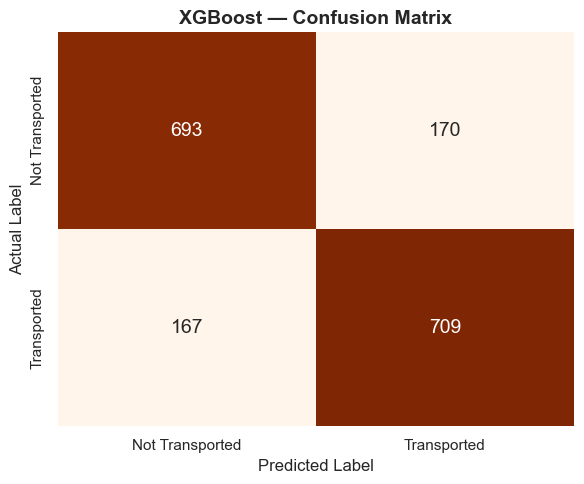


════════════════════════════════════════════════════════════
XGBOOST FEATURE IMPORTANCE
════════════════════════════════════════════════════════════
        Feature  Importance
  IsZeroSpender    0.720489
    LuxurySpend    0.050082
      CryoSleep    0.036988
 HomePlanet_int    0.032964
Planet_Cryo_int    0.032657
 NonLuxurySpend    0.015344
      Route_int    0.014865
  CabinDeck_int    0.011924
  CabinSide_int    0.010793
     TotalSpend    0.007199
      FoodCourt    0.006833
            Spa    0.006712
       CabinNum    0.006363
   AgeGroup_int    0.005988
          Group    0.005866
         VRDeck    0.005546
Destination_int    0.005246
            Age    0.004718
   ShoppingMall    0.004718
    RoomService    0.004276
      GroupSize    0.003768
            VIP    0.003683
        IsAlone    0.002979
════════════════════════════════════════════════════════════


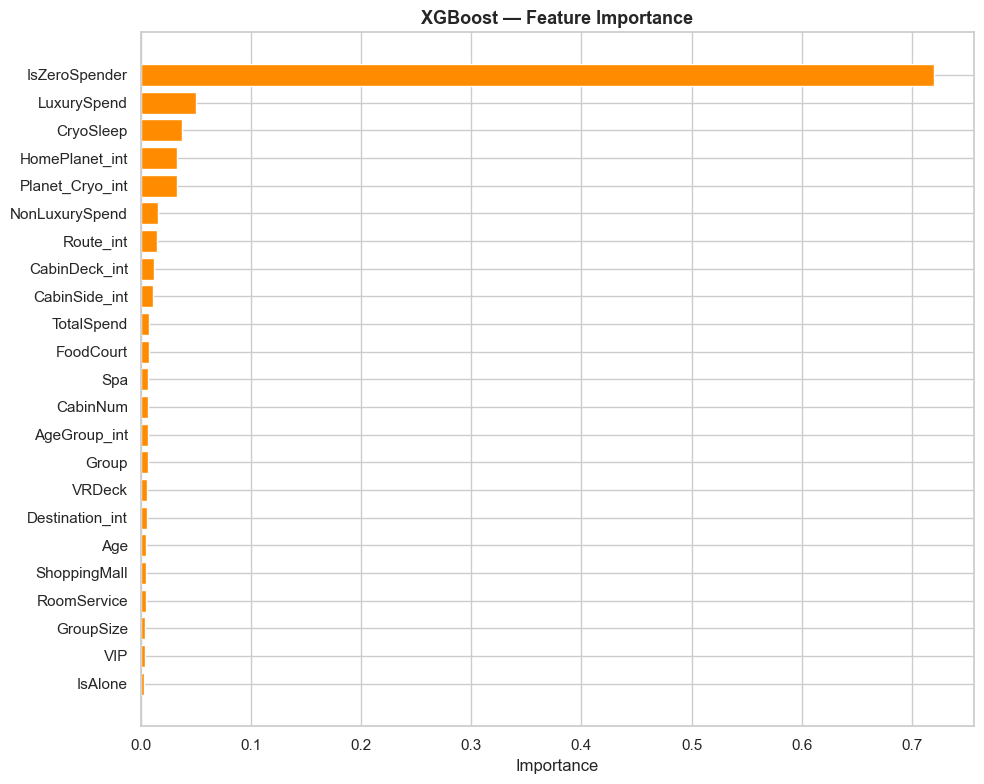


════════════════════════════════════════════════════════════
MODEL COMPARISON SO FAR
════════════════════════════════════════════════════════════
Logistic Regression             Accuracy: 0.7884
Lasso Logistic Regression       Accuracy: 0.7884
XGBoost                         Accuracy: 0.8062
════════════════════════════════════════════════════════════


In [29]:
# ═══════════════════════════════════════════════════════════════════════
# MODEL 3 — XGBOOST (Gradient Boosted Trees)
# Uses the FULL feature set — tree-based models handle multicollinearity
# and nonlinear interactions natively, no manual dropping needed
# ═══════════════════════════════════════════════════════════════════════

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ── Full feature set (same split as before — no scaling needed for trees) ──
X_full = train.drop(columns=['Transported'])
y = train['Transported']

print(f"XGBoost feature set: {X_full.shape}  (using ALL columns, unscaled)\n")

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# ── Base XGBoost model ──
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# ── Predict ──
preds_xgb = xgb_model.predict(X_val)
acc_xgb = accuracy_score(y_val, preds_xgb)

print("Training XGBoost...")
print(f"\nAccuracy : {acc_xgb:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, preds_xgb, target_names=['Not Transported', 'Transported']))

tn, fp, fn, tp = confusion_matrix(y_val, preds_xgb).ravel()

print("=======================================================")
print("WHAT MODEL PREDICTED vs REALITY")
print("=======================================================")
print(f"✅ NOT Transported & Said NOT : {tn}")
print(f"❌ NOT Transported & Said YES : {fp}")
print(f"❌ Transported     & Said NOT : {fn}")
print(f"✅ Transported     & Said YES : {tp}")
print("=======================================================")

# ── Confusion Matrix — Visual ──
cm_xgb = confusion_matrix(y_val, preds_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Not Transported', 'Transported'],
    yticklabels=['Not Transported', 'Transported'],
    cbar=False,
    annot_kws={"size": 14}
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('XGBoost — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE
# ═══════════════════════════════════════════════════════════════════════

importance_df = pd.DataFrame({
    'Feature': X_full.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\n" + "═" * 60)
print("XGBOOST FEATURE IMPORTANCE")
print("═" * 60)
print(importance_df.to_string(index=False))
print("═" * 60)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='darkorange')
plt.xlabel('Importance')
plt.title('XGBoost — Feature Importance', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# STORE RESULT FOR COMPARISON TABLE
# ═══════════════════════════════════════════════════════════════════════

report_dict_xgb = classification_report(
    y_val, preds_xgb, target_names=['Not Transported', 'Transported'], output_dict=True
)

model_results["XGBoost"] = {
    'accuracy': acc_xgb,
    'precision_0': report_dict_xgb['Not Transported']['precision'],
    'precision_1': report_dict_xgb['Transported']['precision'],
    'recall_0': report_dict_xgb['Not Transported']['recall'],
    'recall_1': report_dict_xgb['Transported']['recall'],
    'f1_0': report_dict_xgb['Not Transported']['f1-score'],
    'f1_1': report_dict_xgb['Transported']['f1-score'],
    'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    'total_right': tn + tp,
    'total_wrong': fp + fn
}

# ── Comparison so far ──
print("\n" + "═" * 60)
print("MODEL COMPARISON SO FAR")
print("═" * 60)
for name, res in model_results.items():
    print(f"{name:30s}  Accuracy: {res['accuracy']:.4f}")
print("═" * 60)


Tuned XG Boost

Running RandomizedSearchCV — this may take a few minutes...

Fitting 5 folds for each of 100 candidates, totalling 500 fits

✅ Best CV Accuracy: 0.8108
✅ Best Parameters:
    subsample: 0.7
    reg_lambda: 2
    reg_alpha: 0.01
    n_estimators: 300
    min_child_weight: 7
    max_depth: 8
    learning_rate: 0.02
    gamma: 1
    colsample_bytree: 0.9

Validation Accuracy (Tuned XGBoost): 0.8074

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.80      0.82      0.81       863
    Transported       0.82      0.80      0.81       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739

WHAT MODEL PREDICTED vs REALITY
✅ NOT Transported & Said NOT : 706
❌ NOT Transported & Said YES : 157
❌ Transported     & Said NOT : 178
✅ Transported     & Said YES : 698


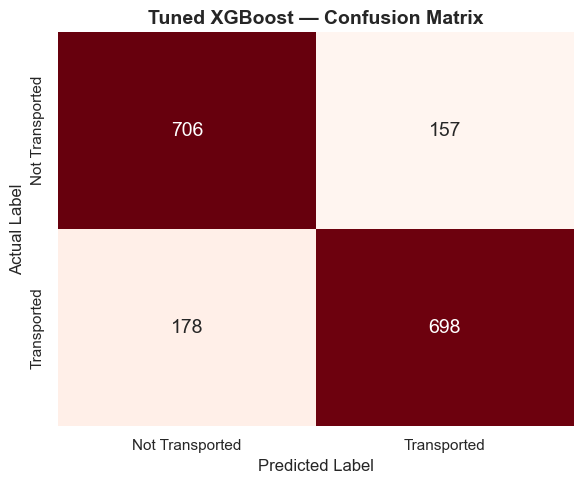


════════════════════════════════════════════════════════════
TUNED XGBOOST FEATURE IMPORTANCE
════════════════════════════════════════════════════════════
        Feature  Importance
  IsZeroSpender    0.616943
    LuxurySpend    0.083298
Planet_Cryo_int    0.059882
 HomePlanet_int    0.032224
 NonLuxurySpend    0.024794
      Route_int    0.019046
  CabinDeck_int    0.016833
      CryoSleep    0.014173
  CabinSide_int    0.013720
      FoodCourt    0.012718
     TotalSpend    0.011119
            Spa    0.009876
       CabinNum    0.009561
         VRDeck    0.009452
          Group    0.008885
Destination_int    0.008116
            Age    0.007929
   ShoppingMall    0.007804
      GroupSize    0.007730
    RoomService    0.007730
   AgeGroup_int    0.007105
        IsAlone    0.006319
            VIP    0.004742
════════════════════════════════════════════════════════════


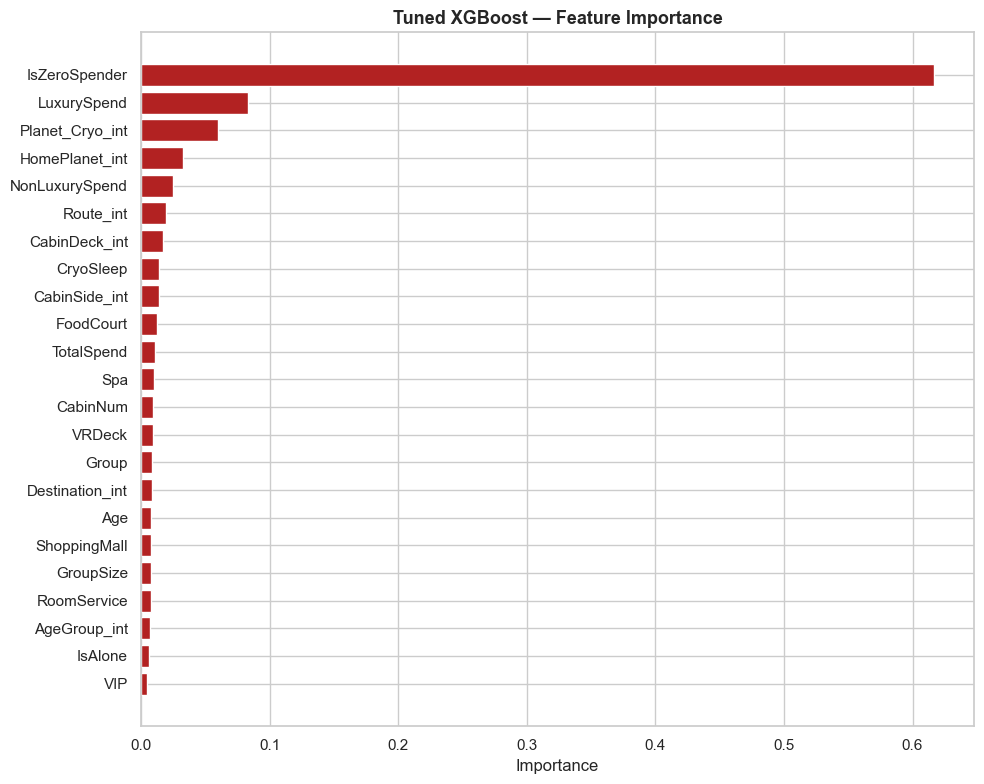


════════════════════════════════════════════════════════════
MODEL COMPARISON SO FAR
════════════════════════════════════════════════════════════
Logistic Regression             Accuracy: 0.7884
Lasso Logistic Regression       Accuracy: 0.7884
XGBoost                         Accuracy: 0.8062
XGBoost (Tuned)                 Accuracy: 0.8074
════════════════════════════════════════════════════════════


In [30]:
# ═══════════════════════════════════════════════════════════════════════
# MODEL 3b — XGBOOST HYPERPARAMETER TUNING (RandomizedSearchCV)
# Faster than GridSearchCV — samples a fixed number of combinations
# from the parameter space rather than testing every single one
# ═══════════════════════════════════════════════════════════════════════

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ── Same split as before (must match for fair comparison) ──
X_full = train.drop(columns=['Transported'])
y = train['Transported']

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# ── Parameter search space ──
param_dist = {
    'n_estimators':     [100, 200, 300, 500, 700],
    'max_depth':        [3, 4, 5, 6, 7, 8],
    'learning_rate':    [0.01, 0.02, 0.05, 0.08, 0.1, 0.15],
    'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma':             [0, 0.1, 0.2, 0.5, 1],
    'reg_alpha':         [0, 0.01, 0.1, 1],
    'reg_lambda':        [0.5, 1, 1.5, 2]
}

base_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

print("Running RandomizedSearchCV — this may take a few minutes...\n")

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=100,             # test 100 random combinations
    scoring='accuracy',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f"\n✅ Best CV Accuracy: {random_search.best_score_:.4f}")
print(f"✅ Best Parameters:")
for k, v in random_search.best_params_.items():
    print(f"    {k}: {v}")

# ── Refit best model and evaluate on validation set ──
best_xgb = random_search.best_estimator_
preds_xgb_tuned = best_xgb.predict(X_val)
acc_xgb_tuned = accuracy_score(y_val, preds_xgb_tuned)

print(f"\nValidation Accuracy (Tuned XGBoost): {acc_xgb_tuned:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, preds_xgb_tuned, target_names=['Not Transported', 'Transported']))

tn, fp, fn, tp = confusion_matrix(y_val, preds_xgb_tuned).ravel()

print("=======================================================")
print("WHAT MODEL PREDICTED vs REALITY")
print("=======================================================")
print(f"✅ NOT Transported & Said NOT : {tn}")
print(f"❌ NOT Transported & Said YES : {fp}")
print(f"❌ Transported     & Said NOT : {fn}")
print(f"✅ Transported     & Said YES : {tp}")
print("=======================================================")

# ── Confusion Matrix — Visual ──
cm_xgb_tuned = confusion_matrix(y_val, preds_xgb_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_xgb_tuned,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Not Transported', 'Transported'],
    yticklabels=['Not Transported', 'Transported'],
    cbar=False,
    annot_kws={"size": 14}
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('Tuned XGBoost — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE (TUNED MODEL)
# ═══════════════════════════════════════════════════════════════════════

importance_df_tuned = pd.DataFrame({
    'Feature': X_full.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\n" + "═" * 60)
print("TUNED XGBOOST FEATURE IMPORTANCE")
print("═" * 60)
print(importance_df_tuned.to_string(index=False))
print("═" * 60)

plt.figure(figsize=(10, 8))
plt.barh(importance_df_tuned['Feature'], importance_df_tuned['Importance'], color='firebrick')
plt.xlabel('Importance')
plt.title('Tuned XGBoost — Feature Importance', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# STORE RESULT FOR COMPARISON TABLE
# ═══════════════════════════════════════════════════════════════════════

report_dict_xgb_tuned = classification_report(
    y_val, preds_xgb_tuned, target_names=['Not Transported', 'Transported'], output_dict=True
)

model_results["XGBoost (Tuned)"] = {
    'accuracy': acc_xgb_tuned,
    'precision_0': report_dict_xgb_tuned['Not Transported']['precision'],
    'precision_1': report_dict_xgb_tuned['Transported']['precision'],
    'recall_0': report_dict_xgb_tuned['Not Transported']['recall'],
    'recall_1': report_dict_xgb_tuned['Transported']['recall'],
    'f1_0': report_dict_xgb_tuned['Not Transported']['f1-score'],
    'f1_1': report_dict_xgb_tuned['Transported']['f1-score'],
    'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    'total_right': tn + tp,
    'total_wrong': fp + fn
}

# ── Comparison so far ──
print("\n" + "═" * 60)
print("MODEL COMPARISON SO FAR")
print("═" * 60)
for name, res in model_results.items():
    print(f"{name:30s}  Accuracy: {res['accuracy']:.4f}")
print("═" * 60)


In [31]:
# ═══════════════════════════════════════════════════════════════════════
# FINAL STEP — PREDICT ON TEST SET & SAVE SUBMISSION CSV
# ═══════════════════════════════════════════════════════════════════════

import pandas as pd

# Raw PassengerId, captured fresh from the original test.csv (unmodified)
test_passenger_ids = pd.read_csv('test.csv')['PassengerId']

# Make sure test columns match X_full's columns exactly (same order)
X_test_final = test[X_full.columns]

# Predict using the tuned model
test_preds = best_xgb.predict(X_test_final)
test_preds_bool = test_preds.astype(bool)   # 1 -> True, 0 -> False

# Build submission dataframe in the required format
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Transported': test_preds_bool
})

submission.to_csv('submission.csv', index=False)

print(f"✅ submission.csv saved! Shape: {submission.shape}")
submission.head(10)


✅ submission.csv saved! Shape: (4277, 2)


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
5,0027_01,True
6,0029_01,True
7,0032_01,True
8,0032_02,True
9,0033_01,True


In [33]:
from sklearn.metrics import accuracy_score

print(f"{'Model':<28}{'Train Acc':<12}{'Val Acc':<12}{'Gap':<10}")
print("-" * 60)

# ── XGBoost (default) — uses unscaled X_train/X_val (full feature set) ──
train_acc = accuracy_score(y_train, xgb_model.predict(X_train))
val_acc   = accuracy_score(y_val, xgb_model.predict(X_val))
print(f"{'XGBoost (default)':<28}{train_acc:<12.4f}{val_acc:<12.4f}{train_acc-val_acc:<10.4f}")

# ── Tuned XGBoost — same X_train/X_val ──
train_acc = accuracy_score(y_train, best_xgb.predict(X_train))
val_acc   = accuracy_score(y_val, best_xgb.predict(X_val))
print(f"{'Tuned XGBoost':<28}{train_acc:<12.4f}{val_acc:<12.4f}{train_acc-val_acc:<10.4f}")

# ── Logistic Regression — needs its OWN scaled data (X_linear-based) ──
train_acc = accuracy_score(y_train_log, log_model.predict(X_train_log_scaled))
val_acc   = accuracy_score(y_val_log, log_model.predict(X_val_log_scaled))
print(f"{'Logistic Regression':<28}{train_acc:<12.4f}{val_acc:<12.4f}{train_acc-val_acc:<10.4f}")

# ── Lasso — needs its OWN scaled data (X_full-based, scaler_lasso) ──
train_acc = accuracy_score(y_train_lasso, lasso_model.predict(X_train_lasso_scaled))
val_acc   = accuracy_score(y_val_lasso, lasso_model.predict(X_val_lasso_scaled))
print(f"{'Lasso Logistic Regression':<28}{train_acc:<12.4f}{val_acc:<12.4f}{train_acc-val_acc:<10.4f}")

from sklearn.metrics import accuracy_score

print(f"{'Model':<28}{'Train Acc':<12}{'Val Acc':<12}{'Gap':<10}")
print("-" * 60)

for name, model in [('XGBoost (default)', xgb_model), ('Tuned XGBoost', best_xgb)]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc   = accuracy_score(y_val, model.predict(X_val))
    gap = train_acc - val_acc
    print(f"{name:<28}{train_acc:<12.4f}{val_acc:<12.4f}{gap:<10.4f}")


Model                       Train Acc   Val Acc     Gap       
------------------------------------------------------------
XGBoost (default)           0.8576      0.8062      0.0514    
Tuned XGBoost               0.8630      0.8074      0.0556    


NameError: name 'y_train_log' is not defined

In [34]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

param_dist_regularized = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],              # shallower than before
    'learning_rate': [0.01, 0.02, 0.05],
    'min_child_weight': [3, 5, 7, 10],       # higher = less overfitting
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_alpha': [0.1, 0.5, 1, 2],           # stronger L1
    'reg_lambda': [1, 2, 5, 10],             # stronger L2
    'gamma': [0, 0.1, 0.5, 1],               # min loss reduction to split further
}

random_search_reg = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
    param_distributions=param_dist_regularized,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search_reg.fit(X_train, y_train)

best_xgb_reg = random_search_reg.best_estimator_

train_acc = accuracy_score(y_train, best_xgb_reg.predict(X_train))
val_acc   = accuracy_score(y_val, best_xgb_reg.predict(X_val))

print("Best params:", random_search_reg.best_params_)
print(f"Train Acc: {train_acc:.4f}")
print(f"Val Acc:   {val_acc:.4f}")
print(f"Gap:       {train_acc - val_acc:.4f}")


Best params: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
Train Acc: 0.8352
Val Acc:   0.8028
Gap:       0.0324


In [35]:
from xgboost import XGBClassifier

xgb_early = XGBClassifier(
    n_estimators=1000,          # set high; early stopping will cut it short
    max_depth=4,
    learning_rate=0.02,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=2,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42
)

xgb_early.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

train_acc = accuracy_score(y_train, xgb_early.predict(X_train))
val_acc   = accuracy_score(y_val, xgb_early.predict(X_val))
print(f"Best iteration: {xgb_early.best_iteration}")
print(f"Train Acc: {train_acc:.4f}")
print(f"Val Acc:   {val_acc:.4f}")
print(f"Gap:       {train_acc - val_acc:.4f}")


Best iteration: 869
Train Acc: 0.8520
Val Acc:   0.8097
Gap:       0.0424


In [36]:
# Refit on full data (need a validation-style split internally for early stopping to work,
# so we carve out a small internal validation slice from X_full)
from sklearn.model_selection import train_test_split

X_full_train, X_full_val, y_full_train, y_full_val = train_test_split(
    X_full, y, test_size=0.1, random_state=42, stratify=y
)

xgb_final = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.02,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=2,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42
)

xgb_final.fit(
    X_full_train, y_full_train,
    eval_set=[(X_full_val, y_full_val)],
    verbose=False
)

print(f"Best iteration: {xgb_final.best_iteration}")

X_test_final = test[X_full.columns]
test_preds_bool = xgb_final.predict(X_test_final).astype(bool)

test_passenger_ids = pd.read_csv('test.csv')['PassengerId']
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Transported': test_preds_bool
})
submission.to_csv('submission_early_stop.csv', index=False)
print("Saved submission_early_stop.csv")
submission.head()


Best iteration: 460
Saved submission_early_stop.csv


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [38]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# ── Keep top N features by importance (from Tuned XGBoost) ──
top_features= importance_df_tuned['Feature'].head(20).tolist()
  # try top 20
print("Keeping features:", top_features)

X_full_trimmed = X_full[top_features]

X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(
    X_full_trimmed, y, test_size=0.2, random_state=42, stratify=y
)

xgb_trimmed = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.02,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=2,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42
)

xgb_trimmed.fit(
    X_train_t, y_train_t,
    eval_set=[(X_val_t, y_val_t)],
    verbose=False
)

train_acc = accuracy_score(y_train_t, xgb_trimmed.predict(X_train_t))
val_acc   = accuracy_score(y_val_t, xgb_trimmed.predict(X_val_t))

print(f"Best iteration: {xgb_trimmed.best_iteration}")
print(f"Train Acc: {train_acc:.4f}")
print(f"Val Acc:   {val_acc:.4f}")
print(f"Gap:       {train_acc - val_acc:.4f}")


Keeping features: ['IsZeroSpender', 'LuxurySpend', 'Planet_Cryo_int', 'HomePlanet_int', 'NonLuxurySpend', 'Route_int', 'CabinDeck_int', 'CryoSleep', 'CabinSide_int', 'FoodCourt', 'TotalSpend', 'Spa', 'CabinNum', 'VRDeck', 'Group', 'Destination_int', 'Age', 'ShoppingMall', 'GroupSize', 'RoomService']
Best iteration: 665
Train Acc: 0.8456
Val Acc:   0.8074
Gap:       0.0382
